In [1]:
pip install torch torchvision numpy scikit-learn monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.8 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import cv2  # OpenCV for image processing
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import torch
from PIL import Image  # Libreria per leggere i file .tif
import torchvision.transforms as T

In [3]:
from torch.utils.data import Dataset
import os
import numpy as np
from PIL import Image  # Libreria per leggere i file .tif

In [4]:
import os
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.io import read_image
from sklearn.model_selection import train_test_split
import torchvision.transforms.functional as TF

In [18]:
#Custom Dataset per processare le immagini 
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_filenames, augmentations=None, transform=None):
        """
        Args:
            image_dir (str): Path to the directory containing images.
            mask_dir (str): Path to the directory containing masks.
            image_filenames (list): List of image filenames (used to locate corresponding masks).
            augmentations (callable, optional): Optional augmentation transforms.
            transform (callable, optional): Optional transforms for normalization, resizing, etc.
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_filenames = image_filenames
        self.augmentations = augmentations
        self.transform = transform

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_filenames[idx])
        mask_path = os.path.join(self.mask_dir, self.image_filenames[idx])  # Assuming masks have the same name
    
        # Load image and mask
        image = read_image(image_path).float() / 255.0
        mask = read_image(mask_path).float()

        # Se la maschera è multi-canale, riconduci a singolo canale
        if mask.shape[0] != 1:
            mask = mask.mean(dim=0, keepdim=True)

        # **Binarizzazione della maschera**
        threshold = 50  # Soglia di binarizzazione
        mask = torch.where(mask < threshold, torch.tensor(0.0), torch.tensor(255.0))
    
        # *** SCALA la maschera in modo dinamico! ***
        mask = mask / 255.0

        # Apply augmentations (only if provided)
        if self.augmentations:
            image, mask = self.augmentations(image, mask)
    
        # Apply transformations (ONLY to images)
        if self.transform:
            image = self.transform(image)  # Normalize image
            mask = T.Resize((512, 512))(mask)  # Resize mask without normalization
    
        return image, mask

In [37]:
#Other lesion non funzionante 
import os
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
from torchvision.io import read_image

class SegmentationDataset(Dataset):
    def __init__(
        self,
        image_dir,
        mask_dir,
        image_filenames,
        augmentations=None,
        transform=None,
        other_lesion=False,
        hemorrhage_dir=None,
        microaneurysm_dir=None,
        soft_exudate_dir=None
    ):
        """
        Args:
            image_dir (str): Path to the directory containing images.
            mask_dir (str): Path to the directory containing hard exudate masks (.tif).
            image_filenames (list): List of image filenames.
            augmentations (callable, optional): Data augmentation function.
            transform (callable, optional): Transformations for normalization, resizing, etc.
            other_lesion (bool): If True, loads additional lesion masks.
            hemorrhage_dir (str): Path to hemorrhage masks (.jpg).
            microaneurysm_dir (str): Path to microaneurysm masks (.jpg).
            soft_exudate_dir (str): Path to soft exudate masks (.jpg).
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_filenames = image_filenames
        self.augmentations = augmentations
        self.transform = transform
        
        self.other_lesion = other_lesion
        self.hemorrhage_dir = hemorrhage_dir
        self.microaneurysm_dir = microaneurysm_dir
        self.soft_exudate_dir = soft_exudate_dir

    def __len__(self):
        return len(self.image_filenames)

    def load_image(self, path):
        """Loads an image using torchvision for .jpg and PIL for .tif."""
        if path.endswith(".tif") or path.endswith(".tiff"):
            return torch.tensor(np.array(Image.open(path)), dtype=torch.float32) / 255.0
        else:
            return read_image(path).float() / 255.0

    def load_mask(self, path):
        """Loads a mask, ensuring it is single-channel and binarized."""
        mask = self.load_image(path).float() 

        # Ensure single-channel mask
        if mask.ndim == 3 and mask.shape[0] != 1:
            mask = mask.mean(dim=0, keepdim=True)

        threshold = 0.5
        mask = torch.where(mask < threshold, 0.0, 1.0)

        return mask

    def __getitem__(self, idx):
        image_name = self.image_filenames[idx]

        # --- Load Image ---
        image_path = os.path.join(self.image_dir, image_name)
        image = self.load_image(image_path)

        # --- Load Hard Exudate Mask (.tif) ---
        mask_path = os.path.join(self.mask_dir, image_name.replace('.jpg', '.tif').replace('.jpeg', '.tif'))
        mask = self.load_mask(mask_path)

        # --- Load Other Lesion Masks (if enabled) ---
        if self.other_lesion:
            hemorrhage_path = os.path.join(self.hemorrhage_dir, image_name.replace('.tif', '.jpg'))
            microaneurysm_path = os.path.join(self.microaneurysm_dir, image_name.replace('.tif', '.jpg'))
            #soft_exudate_path = os.path.join(self.soft_exudate_dir, image_name.replace('.tiff', '.jpg'))

            hemorrhage_mask = self.load_mask(hemorrhage_path)
            micro_mask = self.load_mask(microaneurysm_path)
            #soft_mask = self.load_mask(soft_exudate_path)

            # Combine other lesion masks
            negative_mask = torch.clamp(hemorrhage_mask + micro_mask, 0, 1)
        else:
            negative_mask = torch.zeros_like(mask)

        # --- Data Augmentation ---
        if self.augmentations:
            if self.other_lesion == False:
                image, mask = self.augmentations(image, mask, other_lesion = self.other_lesion)
            else:
                image, mask, negative_mask = self.augmentations(image, mask, negative_mask = negative_mask, 
                                                                other_lesion = self.other_lesion) 

        # --- Final Transformations ---
        if self.transform:
            image = self.transform(image)
            mask = T.Resize((512, 512))(mask)
            if self.other_lesion:
                negative_mask = T.Resize((512, 512))(negative_mask)

        return image, mask, negative_mask

In [5]:
#Ipoteticamente funzionante 
import os
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
from torchvision.io import read_image

class SegmentationDataset(Dataset):
    def __init__(
        self,
        image_dir,
        mask_dir,
        image_filenames,
        augmentations=None,
        transform=None,
        other_lesion=False,
        hemorrhage_dir=None,
        microaneurysm_dir=None,
        soft_exudate_dir=None
    ):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_filenames = image_filenames
        self.augmentations = augmentations
        self.transform = transform
        
        self.other_lesion = other_lesion
        self.hemorrhage_dir = hemorrhage_dir
        self.microaneurysm_dir = microaneurysm_dir
        self.soft_exudate_dir = soft_exudate_dir

    def __len__(self):
        return len(self.image_filenames)

    def load_image(self, path):
        """Loads an image using torchvision for .jpg and PIL for .tif."""
        if path.endswith(".tif") or path.endswith(".tiff"):
            img = np.array(Image.open(path)).astype(np.float32)
            max_val = img.max() if img.max() > 0 else 1  # Avoid division by zero
            img = img / max_val  # Normalize to [0,1]
            return torch.tensor(img, dtype=torch.float32)
        else:
            return read_image(path).float() / 255.0

    def load_mask(self, path):
        """Loads a mask, ensuring it is single-channel and binarized."""
        if not os.path.exists(path):
            print(f"Warning: Mask file not found: {path}")
            return torch.zeros((1, 512, 512), dtype=torch.float32)  # Return empty mask if missing
        
        mask = self.load_image(path).float()

        # Ensure single-channel mask
        if mask.ndim == 3 and mask.shape[0] != 1:
            mask = mask.mean(dim=0, keepdim=True)

        # Binarization
        threshold = 0.5
        mask = torch.where(mask < threshold, 0.0, 1.0)
        
        return mask

    def __getitem__(self, idx):
        image_name = self.image_filenames[idx]

        # --- Load Image ---
        image_path = os.path.join(self.image_dir, image_name)
        image = self.load_image(image_path)

        # --- Load Hard Exudate Mask (.tif) ---
        mask_path = os.path.join(self.mask_dir, image_name.replace('.jpg', '.tif').replace('.jpeg', '.tif'))
        mask = self.load_mask(mask_path)

        # --- Load Other Lesion Masks (if enabled) ---
        if self.other_lesion:
            hemorrhage_path = os.path.join(self.hemorrhage_dir, image_name.replace('.tif', '.jpg'))
            microaneurysm_path = os.path.join(self.microaneurysm_dir, image_name.replace('.tif', '.jpg'))
            
            hemorrhage_mask = self.load_mask(hemorrhage_path)
            micro_mask = self.load_mask(microaneurysm_path)
            
            negative_mask = torch.clamp(hemorrhage_mask + micro_mask, 0, 1)
        else:
            negative_mask = torch.zeros_like(mask)

        # --- Data Augmentation ---
        if self.augmentations:
            if not self.other_lesion:
                image, mask = self.augmentations(image, mask, other_lesion=self.other_lesion)
            else:
                image, mask, negative_mask = self.augmentations(image, mask, negative_mask=negative_mask, 
                                                                other_lesion=self.other_lesion) 

        # --- Final Transformations ---
        if self.transform:
            image = self.transform(image)
            mask = T.Resize((512, 512))(mask)
            mask = torch.where(mask < 0.5, 0.0, 1.0)  # Ensure binary mask after resizing
            if self.other_lesion:
                negative_mask = T.Resize((512, 512))(negative_mask)
                negative_mask = torch.where(negative_mask < 0.5, 0.0, 1.0)  # Ensure binary negative mask

        return image, mask, negative_mask


In [25]:
#Training, validation e test split
import numpy as np
from sklearn.model_selection import train_test_split


image_dir = "/kaggle/input/patches-final2/patches"
mask_dir = "/kaggle/input/labels/labels"
hemorrhage_dir = "/kaggle/input/haemorr-patches/haemorr_patches"
microaneurysm_dir = "/kaggle/input/micro-patches/micro_patches"
#soft_exudate_dir = "/kaggle/input/soft-patches/soft_patches"


# Get list of all filenames in the image directory
image_filenames = os.listdir(image_dir)

# Shuffle and split filenames into train, validation, and test sets
np.random.shuffle(image_filenames)
train_files, val_files = train_test_split(image_filenames, test_size=0.1, random_state=42)  # 90% train

print(f"Train: {len(train_files)}, Validation: {len(val_files)}")

Train: 7774, Validation: 864


In [26]:
# Augmentation function for training data
def augmentations(image, mask):
    # Random horizontal flip
    if random.random() > 0.5:
        image = T.functional.hflip(image)
        mask = T.functional.hflip(mask)
    # Random vertical flip
    if random.random() > 0.5:
        image = T.functional.vflip(image)
        mask = T.functional.vflip(mask)
    # Random brightness adjustment
    brightness_factor = random.uniform(0.8, 1.2)
    image = T.functional.adjust_brightness(image, brightness_factor)
    # Random hue adjustment
    hue_factor = random.uniform(-0.05, 0.05)
    image = T.functional.adjust_hue(image, hue_factor)

    return image, mask

# Final transformations (applied to all datasets)
final_transforms = T.Compose([
    T.Resize((512, 512))  # Resize images and masks
])

In [7]:
#Con altre lesioni 
import random
import torchvision.transforms.functional as F

# Augmentation function for training data
def augmentations(image, mask, negative_mask= None, other_lesion=False):
    # Random horizontal flip
    if random.random() > 0.5:
        image = T.functional.hflip(image)
        mask = T.functional.hflip(mask)
        if other_lesion == True:
            negative_mask = T.functional.hflip(negative_mask)
            
    # Random vertical flip
    if random.random() > 0.5:
        image = T.functional.vflip(image)
        mask = T.functional.vflip(mask)
        if other_lesion == True:
            negative_mask = negative_mask = T.functional.vflip(negative_mask)
            
    # Random brightness adjustment
    brightness_factor = random.uniform(0.8, 1.2)
    image = T.functional.adjust_brightness(image, brightness_factor)
    # Random hue adjustment
    hue_factor = random.uniform(-0.05, 0.05)
    image = T.functional.adjust_hue(image, hue_factor)

    if other_lesion == False:
        return image, mask
    else:
         return image, mask, negative_mask

# Final transformations (applied to all datasets)
final_transforms = T.Compose([
    T.Resize((512, 512))  # Resize images and masks
])


In [27]:
# Create datasets
train_dataset = SegmentationDataset(
    image_dir=image_dir,
    mask_dir=mask_dir,
    image_filenames=train_files,
    augmentations=augmentations,  # Apply augmentations only to training
    transform=final_transforms
)

val_dataset = SegmentationDataset(
    image_dir=image_dir,
    mask_dir=mask_dir,
    image_filenames=val_files,
    augmentations=None,  # No augmentations for validation
    transform=final_transforms
)

In [8]:
#Con altre lesioni
# Create datasets
train_dataset = SegmentationDataset(
    image_dir=image_dir,
    mask_dir=mask_dir,
    hemorrhage_dir = hemorrhage_dir,
    microaneurysm_dir = microaneurysm_dir,
    #soft_exudate_dir = soft_exudate_dir,
    other_lesion= True,
    image_filenames=train_files,
    augmentations=augmentations,  # Apply augmentations only to training
    transform=final_transforms
)

val_dataset = SegmentationDataset(
    image_dir=image_dir,
    mask_dir=mask_dir,
    hemorrhage_dir = hemorrhage_dir,
    microaneurysm_dir = microaneurysm_dir,
    #soft_exudate_dir = soft_exudate_dir,
    other_lesion= True,
    image_filenames=val_files,
    augmentations=None,  # No augmentations for validation
    transform=final_transforms
)

In [29]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import average_precision_score

# Abilita cuDNN auto-tuner per ottimizzare il training su GPU
torch.backends.cudnn.benchmark = True

# Usa GPU se disponibile
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Funzione di Loss Ponderata per affrontare squilibri di classe
class WeightedBCELoss(nn.Module):
    def __init__(self, pos_weight=8):
        super(WeightedBCELoss, self).__init__()
        self.pos_weight = torch.tensor(pos_weight, device=device)
    
    def forward(self, y_pred, y_true):
        return F.binary_cross_entropy_with_logits(y_pred, y_true, pos_weight=self.pos_weight)


# Funzione Balanced Dice Loss
def balanced_dice_loss(y_pred, y_true, beta=0.5, smooth=1e-6):
    y_pred = torch.sigmoid(y_pred)  # Converti i logit in probabilità
    intersection = (y_pred * y_true).sum()
    dice = (1 + beta**2) * intersection / (beta**2 * y_true.sum() + y_pred.sum() + smooth)
    return 1 - dice


# Funzione Generale per il Training del Modello
def train_model(model, train_dataset, val_dataset, batch_size=32, num_epochs=50, lr=1e-4, pos_weight=8):
    """
    Allena un modello di segmentazione e restituisce train_loss, val_loss e val_aupr.

    Args:
    - model (torch.nn.Module): modello di segmentazione (es. SwinUNETR, U-Net, DeepLabV3).
    - train_dataset (Dataset): dataset di training.
    - val_dataset (Dataset): dataset di validazione.
    - batch_size (int): dimensione del batch.
    - num_epochs (int): numero di epoche di training (default=20).
    - lr (float): learning rate (default=1e-4).
    - pos_weight (float): peso per la classe positiva nella BCE (default=8).

    Returns:
    - train_losses (list): lista delle train loss per ogni epoca.
    - val_losses (list): lista delle validation loss per ogni epoca.
    - val_auprs (list): lista dei valori di AUPR per ogni epoca.
    """

    # Creazione DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    model.to(device)
    
    criterion_bce = WeightedBCELoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.amp.GradScaler() # Mixed precision training

    train_losses, val_losses, val_auprs = [], [], []
    best_val_loss = float('inf')

    eps = 1e-7  # Per evitare divisioni per zero
    threshold = 0.5  # Soglia per binarizzare le predizioni

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_total_tp, train_total_fp, train_total_fn = 0.0, 0.0, 0.0, 0.0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)
                loss_bce = criterion_bce(outputs, masks)
                loss_dice = balanced_dice_loss(outputs, masks)
                loss = loss_bce + loss_dice  # Combiniamo BCE e Dice Loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

            # Metriche binarizzate
            with torch.no_grad():
                y_pred = torch.sigmoid(outputs)
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()

                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()

                train_total_tp += tp.item()
                train_total_fp += fp.item()
                train_total_fn += fn.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        train_precision = train_total_tp / (train_total_tp + train_total_fp + eps)
        train_recall = train_total_tp / (train_total_tp + train_total_fn + eps)
        train_f1 = 2 * (train_precision * train_recall) / (train_precision + train_recall + eps)
        train_dice = 2 * train_total_tp / (2 * train_total_tp + train_total_fp + train_total_fn + eps)

        # Loop di Validazione
        model.eval()
        val_loss, val_total_tp, val_total_fp, val_total_fn = 0.0, 0.0, 0.0, 0.0
        all_val_probs, all_val_targets = [], []

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)

                with torch.amp.autocast(device_type="cuda"):
                    outputs = model(images)
                    loss_bce = criterion_bce(outputs, masks)
                    loss_dice = balanced_dice_loss(outputs, masks)
                    loss = loss_bce + loss_dice  # Combiniamo BCE e Dice Loss

                val_loss += loss.item()

                y_pred = torch.sigmoid(outputs)
                all_val_probs.append(y_pred.cpu().numpy().astype(np.float16).ravel())
                all_val_targets.append(masks.cpu().numpy().astype(np.float16).ravel())

                # Metriche binarizzate
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()

                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()

                val_total_tp += tp.item()
                val_total_fp += fp.item()
                val_total_fn += fn.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        val_precision = val_total_tp / (val_total_tp + val_total_fp + eps)
        val_recall = val_total_tp / (val_total_tp + val_total_fn + eps)
        val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + eps)
        val_dice = 2 * val_total_tp / (2 * val_total_tp + val_total_fp + val_total_fn + eps)

        # Calcolo AUPR
        all_val_probs = np.concatenate(all_val_probs, axis=0)
        all_val_targets = np.concatenate(all_val_targets, axis=0)
        val_aupr = average_precision_score(all_val_targets, all_val_probs)
        val_auprs.append(val_aupr)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | Train Dice: {train_dice:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f} | Val Dice: {val_dice:.4f} | Val AUPR: {val_aupr:.4f}")

        torch.cuda.empty_cache()

    model_name = model.__class__.__name__

    model_filename = f"{model_name}_weights.pth"
    # Salva il modello
    torch.save(model.state_dict(), model_filename)

    return train_losses, val_losses, val_auprs

In [36]:
#Nuova prova 
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import average_precision_score

# Abilita cuDNN auto-tuner per ottimizzare il training su GPU
torch.backends.cudnn.benchmark = True

# Usa GPU se disponibile
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Funzione di Loss Ponderata per affrontare squilibri di classe
class WeightedBCELoss(nn.Module):
    def __init__(self, pos_weight=8):
        super(WeightedBCELoss, self).__init__()
        self.pos_weight = torch.tensor(pos_weight, device=device)
    
    def forward(self, y_pred, y_true):
        return F.binary_cross_entropy_with_logits(y_pred, y_true, pos_weight=self.pos_weight)


# # Funzione Balanced Dice Loss
# def balanced_dice_loss(y_pred, y_true, beta=0.5, smooth=1e-6):
#     y_pred = torch.sigmoid(y_pred)  # Converti i logit in probabilità
#     intersection = (y_pred * y_true).sum()
#     dice = (1 + beta**2) * intersection / (beta**2 * y_true.sum() + y_pred.sum() + smooth)
#     return 1 - dice


# Funzione Generale per il Training del Modello
def train_model(model, train_dataset, val_dataset, batch_size=32, num_epochs=50, lr=1e-4, pos_weight=8):
    """
    Allena un modello di segmentazione e restituisce train_loss, val_loss e val_aupr.

    Args:
    - model (torch.nn.Module): modello di segmentazione (es. SwinUNETR, U-Net, DeepLabV3).
    - train_dataset (Dataset): dataset di training.
    - val_dataset (Dataset): dataset di validazione.
    - batch_size (int): dimensione del batch.
    - num_epochs (int): numero di epoche di training (default=20).
    - lr (float): learning rate (default=1e-4).
    - pos_weight (float): peso per la classe positiva nella BCE (default=8).

    Returns:
    - train_losses (list): lista delle train loss per ogni epoca.
    - val_losses (list): lista delle validation loss per ogni epoca.
    - val_auprs (list): lista dei valori di AUPR per ogni epoca.
    """

    # Creazione DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    model.to(device)
    
    criterion_bce = WeightedBCELoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.amp.GradScaler() # Mixed precision training

    train_losses, val_losses, val_auprs = [], [], []
    best_val_loss = float('inf')

    eps = 1e-7  # Per evitare divisioni per zero
    threshold = 0.5  # Soglia per binarizzare le predizioni

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_total_tp, train_total_fp, train_total_fn = 0.0, 0.0, 0.0, 0.0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)
                loss_bce = criterion_bce(outputs, masks)
                #loss_dice = balanced_dice_loss(outputs, masks)
                loss = loss_bce #+ loss_dice  # Combiniamo BCE e Dice Loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

            # Metriche binarizzate
            with torch.no_grad():
                y_pred = torch.sigmoid(outputs)
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()

                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()

                train_total_tp += tp.item()
                train_total_fp += fp.item()
                train_total_fn += fn.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        train_precision = train_total_tp / (train_total_tp + train_total_fp + eps)
        train_recall = train_total_tp / (train_total_tp + train_total_fn + eps)
        train_f1 = 2 * (train_precision * train_recall) / (train_precision + train_recall + eps)
        train_dice = 2 * train_total_tp / (2 * train_total_tp + train_total_fp + train_total_fn + eps)

        # Loop di Validazione
        model.eval()
        val_loss, val_total_tp, val_total_fp, val_total_fn = 0.0, 0.0, 0.0, 0.0
        all_val_probs, all_val_targets = [], []

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)

                with torch.amp.autocast(device_type="cuda"):
                    outputs = model(images)
                    loss_bce = criterion_bce(outputs, masks)
                    #loss_dice = balanced_dice_loss(outputs, masks)
                    loss = loss_bce #+ loss_dice  # Combiniamo BCE e Dice Loss

                val_loss += loss.item()

                y_pred = torch.sigmoid(outputs)
                all_val_probs.append(y_pred.cpu().numpy().astype(np.float16).ravel())
                all_val_targets.append(masks.cpu().numpy().astype(np.float16).ravel())

                # Metriche binarizzate
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()

                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()

                val_total_tp += tp.item()
                val_total_fp += fp.item()
                val_total_fn += fn.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        val_precision = val_total_tp / (val_total_tp + val_total_fp + eps)
        val_recall = val_total_tp / (val_total_tp + val_total_fn + eps)
        val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + eps)
        val_dice = 2 * val_total_tp / (2 * val_total_tp + val_total_fp + val_total_fn + eps)

        # Calcolo AUPR
        all_val_probs = np.concatenate(all_val_probs, axis=0)
        all_val_targets = np.concatenate(all_val_targets, axis=0)
        val_aupr = average_precision_score(all_val_targets, all_val_probs)
        val_auprs.append(val_aupr)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | Train Dice: {train_dice:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f} | Val Dice: {val_dice:.4f} | Val AUPR: {val_aupr:.4f}")

        torch.cuda.empty_cache()

    model_name = model.__class__.__name__

    model_filename = f"{model_name}_weights.pth"
    # Salva il modello
    torch.save(model.state_dict(), model_filename)

    return train_losses, val_losses, val_auprs

In [10]:
#Other lesion 
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import average_precision_score

# Abilita cuDNN auto-tuner per ottimizzare il training su GPU
torch.backends.cudnn.benchmark = True

# Usa GPU se disponibile
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Funzione di Loss Ponderata per affrontare squilibri di classe
class WeightedBCELoss(nn.Module):
    def __init__(self, pos_weight=8):
        super(WeightedBCELoss, self).__init__()
        self.pos_weight = torch.tensor(pos_weight, device=device)

    def forward(self, y_pred, y_true):
    # Assicuriamoci che y_true abbia la stessa dimensione di y_pred
        if y_true.ndim == 3:  # (Batch, H, W) → Aggiungere dimensione del canale
            y_true = y_true.unsqueeze(1)  # (Batch, 1, H, W)
    
        return F.binary_cross_entropy_with_logits(y_pred, y_true, pos_weight=self.pos_weight)



# Funzione Balanced Dice Loss
def balanced_dice_loss(y_pred, y_true, beta=0.5, smooth=1e-6):
    # y_pred: logits (prima della sigmoid)
    y_prob = torch.sigmoid(y_pred)  # Converti i logit in probabilità
    intersection = (y_prob * y_true).sum()
    dice = (1 + beta**2) * intersection / (beta**2 * y_true.sum() + y_prob.sum() + smooth)
    return 1 - dice


def train_model(
    model, 
    train_dataset, 
    val_dataset, 
    batch_size=32, 
    num_epochs=50, 
    lr=1e-4, 
    pos_weight=8,
    other_lesion=False, 
    penalty_alpha=5.0
):
    """
    Allena un modello di segmentazione e restituisce train_loss, val_loss e val_aupr.
    Se 'other_lesion=True', aggiunge una penalità sui falsi positivi nella negative_mask 
    (regioni di altre lesioni).

    Args:
        model (torch.nn.Module): modello di segmentazione (es. SwinUNETR, U-Net, DeepLabV3).
        train_dataset (Dataset): dataset di training (restituisce (immagine, maschera) 
                                o (immagine, maschera, negative_mask) se other_lesion=True).
        val_dataset (Dataset): dataset di validazione (stessa logica di cui sopra).
        batch_size (int): dimensione del batch.
        num_epochs (int): numero di epoche di training.
        lr (float): learning rate.
        pos_weight (float): peso per la classe positiva nella BCE.
        other_lesion (bool): se True, si aspetta che il dataset restituisca anche negative_mask
                             e aggiunge la penalità in loss.
        penalty_alpha (float): peso della penalità sulle regioni negative.

    Returns:
        train_losses (list): lista delle train loss per ogni epoca.
        val_losses (list): lista delle validation loss per ogni epoca.
        val_auprs (list): lista dei valori di AUPR per ogni epoca.
    """

    # Creazione DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    model.to(device)
    
    criterion_bce = WeightedBCELoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.amp.GradScaler()  # Mixed precision training

    train_losses, val_losses, val_auprs = [], [], []
    best_val_loss = float('inf')

    eps = 1e-7  # Per evitare divisioni per zero
    threshold = 0.5  # Soglia per binarizzare le predizioni

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_total_tp, train_total_fp, train_total_fn = 0.0, 0.0, 0.0

        # ---------- TRAINING LOOP ----------
        for batch_data in train_loader:
            # Se other_lesion=True, dataset restituisce (immagine, mask, negative_mask)
            # Altrimenti (immagine, mask)
            if other_lesion:
                images, masks, neg_masks = batch_data
                images, masks, neg_masks = images.to(device), masks.to(device), neg_masks.to(device)
            else:
                images, masks = batch_data
                images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)  # logits
                loss_bce = criterion_bce(outputs, masks)
                loss_dice = balanced_dice_loss(outputs, masks)
                loss = loss_bce + loss_dice

                # Se ho la negative_mask, aggiungo penalità per i falsi positivi in regioni "negative"
                if other_lesion:
                    y_prob = torch.sigmoid(outputs)
                    penalty = penalty_alpha * (y_prob * neg_masks).mean()
                    loss += penalty

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

            # Calcolo metriche binarie (solo su maschera principale)
            with torch.no_grad():
                y_pred = torch.sigmoid(outputs)
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()

                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()

                train_total_tp += tp.item()
                train_total_fp += fp.item()
                train_total_fn += fn.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        train_precision = train_total_tp / (train_total_tp + train_total_fp + eps)
        train_recall = train_total_tp / (train_total_tp + train_total_fn + eps)
        train_f1 = 2 * (train_precision * train_recall) / (train_precision + train_recall + eps)
        train_dice = 2 * train_total_tp / (2 * train_total_tp + train_total_fp + train_total_fn + eps)

        # ---------- VALIDATION LOOP ----------
        model.eval()
        val_loss = 0.0
        val_total_tp, val_total_fp, val_total_fn = 0.0, 0.0, 0.0
        all_val_probs, all_val_targets = [], []

        with torch.no_grad():
            for batch_data in val_loader:
                if other_lesion:
                    images, masks, neg_masks = batch_data
                    images, masks, neg_masks = images.to(device), masks.to(device), neg_masks.to(device)
                else:
                    images, masks = batch_data
                    images, masks = images.to(device), masks.to(device)

                with torch.amp.autocast(device_type="cuda"):
                    outputs = model(images)
                    loss_bce = criterion_bce(outputs, masks)
                    loss_dice = balanced_dice_loss(outputs, masks)
                    loss = loss_bce + loss_dice

                    if other_lesion:
                        y_prob = torch.sigmoid(outputs)
                        penalty = penalty_alpha * (y_prob * neg_masks).mean()
                        loss += penalty

                val_loss += loss.item()

                # Salviamo per calcolo AUPR
                y_pred = torch.sigmoid(outputs)
                all_val_probs.append(y_pred.cpu().numpy().astype(np.float16).ravel())
                all_val_targets.append(masks.cpu().numpy().astype(np.float16).ravel())

                # Metriche binarie
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()

                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()

                val_total_tp += tp.item()
                val_total_fp += fp.item()
                val_total_fn += fn.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        val_precision = val_total_tp / (val_total_tp + val_total_fp + eps)
        val_recall = val_total_tp / (val_total_tp + val_total_fn + eps)
        val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + eps)
        val_dice = 2 * val_total_tp / (2 * val_total_tp + val_total_fp + val_total_fn + eps)

        # Calcolo AUPR
        all_val_probs = np.concatenate(all_val_probs, axis=0)
        all_val_targets = np.concatenate(all_val_targets, axis=0)
        val_aupr = average_precision_score(all_val_targets, all_val_probs)
        val_auprs.append(val_aupr)

        print(f"Epoch {epoch+1}/{num_epochs} "
              f"| Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | Train Dice: {train_dice:.4f} "
              f"| Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f} | Val Dice: {val_dice:.4f} | Val AUPR: {val_aupr:.4f}")

        torch.cuda.empty_cache()

    # Salvataggio finale pesi
    model_name = model.__class__.__name__
    model_filename = f"{model_name}_weights.pth"
    torch.save(model.state_dict(), model_filename)

    return train_losses, val_losses, val_auprs

## UNet

In [37]:
#Modello
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    """Convolutional Block: {Conv -> BN -> ReLU} x 2"""
    def __init__(self, in_channels, out_channels, reg=0.1):
        super(ConvBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.reg = reg  # Regularization not directly used in PyTorch, weight decay should be applied in optimizer

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return x


class UpConvConcat(nn.Module):
    """Upsample `inputA` and concatenate with `inputB`"""
    def __init__(self, in_channels, out_channels):
        super(UpConvConcat, self).__init__()
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, inputA, inputB):
        upsampled = self.upconv(inputA)
        return torch.cat([upsampled, inputB], dim=1)  # Concatenate along channel dimension


class UNet(nn.Module):
    """U-Net Architecture"""
    def __init__(self, in_channels=3, out_channels=1, reg=0.1):
        super(UNet, self).__init__()

        # Encoder (Downsampling)
        self.conv1 = ConvBlock(in_channels, 16, reg)
        self.conv2 = ConvBlock(16, 32, reg)
        self.conv3 = ConvBlock(32, 64, reg)
        self.conv4 = ConvBlock(64, 128, reg)
        self.conv5 = ConvBlock(128, 256, reg)
        self.conv6 = ConvBlock(256, 512, reg)
        self.conv7 = ConvBlock(512, 1024, reg)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Decoder (Upsampling)
        self.up8 = UpConvConcat(1024, 512)
        self.conv8 = ConvBlock(1024, 512, reg)

        self.up9 = UpConvConcat(512, 256)
        self.conv9 = ConvBlock(512, 256, reg)

        self.up10 = UpConvConcat(256, 128)
        self.conv10 = ConvBlock(256, 128, reg)

        self.up11 = UpConvConcat(128, 64)
        self.conv11 = ConvBlock(128, 64, reg)

        self.up12 = UpConvConcat(64, 32)
        self.conv12 = ConvBlock(64, 32, reg)

        self.up13 = UpConvConcat(32, 16)
        self.conv13 = ConvBlock(32, 16, reg)

        # Final Convolution (1x1 conv to get desired number of output channels)
        self.final = nn.Conv2d(16, out_channels, kernel_size=1)

    def forward(self, x):
        #x = x / 127.5 - 1  # Porta i valori da [0,255] a [-1,1]
        
        # Encoder
        conv1 = self.conv1(x)
        pool1 = self.pool(conv1)

        conv2 = self.conv2(pool1)
        pool2 = self.pool(conv2)

        conv3 = self.conv3(pool2)
        pool3 = self.pool(conv3)

        conv4 = self.conv4(pool3)
        pool4 = self.pool(conv4)

        conv5 = self.conv5(pool4)
        pool5 = self.pool(conv5)

        conv6 = self.conv6(pool5)
        pool6 = self.pool(conv6)

        conv7 = self.conv7(pool6)

        # Decoder
        up8 = self.up8(conv7, conv6)
        conv8 = self.conv8(up8)

        up9 = self.up9(conv8, conv5)
        conv9 = self.conv9(up9)

        up10 = self.up10(conv9, conv4)
        conv10 = self.conv10(up10)

        up11 = self.up11(conv10, conv3)
        conv11 = self.conv11(up11)

        up12 = self.up12(conv11, conv2)
        conv12 = self.conv12(up12)

        up13 = self.up13(conv12, conv1)
        conv13 = self.conv13(up13)

        # Output layer (sigmoid activation for binary segmentation)
        return self.final(conv13)

In [38]:
# Inizializza il modello
model = UNet(in_channels=3, out_channels=1)



# Allenamento
train_losses, val_losses, val_auprs = train_model(
    model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size = 32,
    num_epochs=50,
    lr=1e-4
)

Epoch 1/50 | Train Loss: 0.5641 | Train F1: 0.0340 | Train Dice: 0.0340 | Val Loss: 0.4672 | Val F1: 0.2236 | Val Dice: 0.2236 | Val AUPR: 0.3063
Epoch 2/50 | Train Loss: 0.4353 | Train F1: 0.3464 | Train Dice: 0.3464 | Val Loss: 0.3932 | Val F1: 0.4280 | Val Dice: 0.4280 | Val AUPR: 0.5706
Epoch 3/50 | Train Loss: 0.3755 | Train F1: 0.4637 | Train Dice: 0.4637 | Val Loss: 0.3401 | Val F1: 0.5542 | Val Dice: 0.5542 | Val AUPR: 0.7076
Epoch 4/50 | Train Loss: 0.3322 | Train F1: 0.5133 | Train Dice: 0.5133 | Val Loss: 0.3096 | Val F1: 0.5970 | Val Dice: 0.5970 | Val AUPR: 0.7030
Epoch 5/50 | Train Loss: 0.2958 | Train F1: 0.5613 | Train Dice: 0.5613 | Val Loss: 0.2642 | Val F1: 0.6503 | Val Dice: 0.6503 | Val AUPR: 0.7703
Epoch 6/50 | Train Loss: 0.2680 | Train F1: 0.5569 | Train Dice: 0.5569 | Val Loss: 0.2516 | Val F1: 0.6010 | Val Dice: 0.6010 | Val AUPR: 0.7003
Epoch 7/50 | Train Loss: 0.2458 | Train F1: 0.5466 | Train Dice: 0.5466 | Val Loss: 0.2244 | Val F1: 0.5613 | Val Dice: 0.56

In [ ]:
# Inizializza il modello
model = UNet(in_channels=3, out_channels=1)


# Allenamento
train_losses, val_losses, val_auprs = train_model(
    model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size = 32,
    num_epochs=50,
    lr=1e-4,
    other_lesion = True
)

In [ ]:
#Other lesions 

# Inizializza il modello
model = UNet(in_channels=3, out_channels=1)

train_losses, val_losses, val_auprs = train_model(
    model,
    train_dataset, 
    val_dataset, 
    batch_size=32, 
    num_epochs=20, 
    lr=1e-4, 
    pos_weight=8,
    other_lesion=True,     # Attivo la penalità
    penalty_alpha=0.001    # Esempio di peso della penalità
)

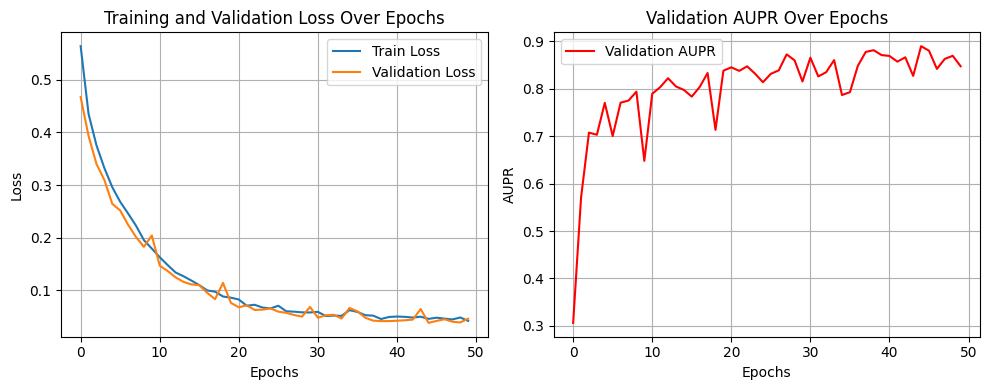

In [40]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

epochs = list(range(50))
# Plot Training and Validation Loss
axes[0].plot(epochs, train_losses, label="Train Loss", linestyle='-')
axes[0].plot(epochs, val_losses, label="Validation Loss", linestyle='-')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss Over Epochs")
axes[0].legend()
axes[0].grid(True)

# Plot Validation AUPR
axes[1].plot(epochs, val_auprs, label="Validation AUPR", color='r', linestyle='-')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("AUPR")
axes[1].set_title("Validation AUPR Over Epochs")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [18]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from torch.cuda.amp import autocast, GradScaler

# Librerie aggiuntive per metriche
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Enable cuDNN auto-tuner
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class WeightedBCELoss(nn.Module):
    def __init__(self, pos_weight=8):
        super(WeightedBCELoss, self).__init__()
        self.pos_weight = torch.tensor(pos_weight, device=device)
    
    def forward(self, y_pred, y_true):
        return F.binary_cross_entropy_with_logits(y_pred, y_true, pos_weight=self.pos_weight)

def main():
    print("Using device:", device)

    # Hyperparameters
    num_epochs = 20
    learning_rate = 1e-4
    eps = 1e-7
    threshold = 0.5

    # Inizializza model, loss, optimizer
    model = UNet(in_channels=3, out_channels=1).to(device)
    criterion = WeightedBCELoss(pos_weight=8)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    # GradScaler per Mixed Precision
    scaler = torch.amp.GradScaler()

    # Lists to store loss and AUPR values
    train_losses = []
    val_losses = []
    train_f1_scores = []
    val_auprs = []
    val_f1_scores = []
    val_precisions = []
    val_recalls = []
    
    for epoch in range(num_epochs):
        model.train()
        
        train_loss = 0.0
        train_total_tp = 0.0
        train_total_fp = 0.0
        train_total_fn = 0.0
    
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
    
            optimizer.zero_grad()
            
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, masks)
    
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
    
            train_loss += loss.item()
    
            # Binarized metrics
            with torch.no_grad():
                y_pred = torch.sigmoid(outputs)
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()
    
                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()
    
                train_total_tp += tp.item()
                train_total_fp += fp.item()
                train_total_fn += fn.item()
    
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
    
        train_precision = train_total_tp / (train_total_tp + train_total_fp + eps)
        train_recall = train_total_tp / (train_total_tp + train_total_fn + eps)
        train_f1 = 2 * (train_precision * train_recall) / (train_precision + train_recall + eps)
        train_f1_scores.append(train_f1)
    
        # --- Validation Loop ---
        model.eval()
        val_loss = 0.0
        all_val_probs = []
        all_val_targets = []
        
        val_total_tp = 0.0
        val_total_fp = 0.0
        val_total_fn = 0.0
    
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
    
                with torch.amp.autocast(device_type="cuda"):
                    outputs = model(images)
                    loss = criterion(outputs, masks)
    
                val_loss += loss.item()
    
                y_pred = torch.sigmoid(outputs)
                all_val_probs.append(y_pred.cpu().numpy().astype(np.float16).ravel())
                all_val_targets.append(masks.cpu().numpy().astype(np.float16).ravel())
    
                # Binarized metrics
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()
    
                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()
    
                val_total_tp += tp.item()
                val_total_fp += fp.item()
                val_total_fn += fn.item()
    
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
    
        val_precision = val_total_tp / (val_total_tp + val_total_fp + eps)
        val_recall = val_total_tp / (val_total_tp + val_total_fn + eps)
        val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + eps)
        val_f1_scores.append(val_f1)
        val_precisions.append(val_precision)
        val_recalls.append(val_recall)
    
        # Compute AUPR for validation
        all_val_probs = np.concatenate(all_val_probs, axis=0)
        all_val_targets = np.concatenate(all_val_targets, axis=0)
        val_aupr = average_precision_score(all_val_targets, all_val_probs)
        val_auprs.append(val_aupr)
    
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f} | "
              f"Val Precision: {val_precision:.4f} | Val Recall: {val_recall:.4f} | "
              f"Val AUPR: {val_aupr:.4f}")
        torch.cuda.empty_cache()
    
    # Save model
    torch.save(model.state_dict(), "unet_segmentation.pth")

if __name__ == "__main__":
    main()

Using device: cuda
Epoch 1/20 | Train Loss: 0.6482 | Train F1: 0.0683 | Val Loss: 0.5589 | Val F1: 0.3631 | Val Precision: 0.2358 | Val Recall: 0.7892 | Val AUPR: 0.6484
Epoch 2/20 | Train Loss: 0.5311 | Train F1: 0.3298 | Val Loss: 0.4786 | Val F1: 0.5242 | Val Precision: 0.3699 | Val Recall: 0.8996 | Val AUPR: 0.7557
Epoch 3/20 | Train Loss: 0.4518 | Train F1: 0.4848 | Val Loss: 0.4157 | Val F1: 0.4799 | Val Precision: 0.3213 | Val Recall: 0.9480 | Val AUPR: 0.8053
Epoch 4/20 | Train Loss: 0.3866 | Train F1: 0.5321 | Val Loss: 0.3561 | Val F1: 0.5325 | Val Precision: 0.3737 | Val Recall: 0.9263 | Val AUPR: 0.7951
Epoch 5/20 | Train Loss: 0.3320 | Train F1: 0.5493 | Val Loss: 0.2979 | Val F1: 0.6362 | Val Precision: 0.4832 | Val Recall: 0.9308 | Val AUPR: 0.8491
Epoch 6/20 | Train Loss: 0.2873 | Train F1: 0.5694 | Val Loss: 0.2503 | Val F1: 0.6145 | Val Precision: 0.4563 | Val Recall: 0.9406 | Val AUPR: 0.8419
Epoch 7/20 | Train Loss: 0.2477 | Train F1: 0.5838 | Val Loss: 0.2333 | Val

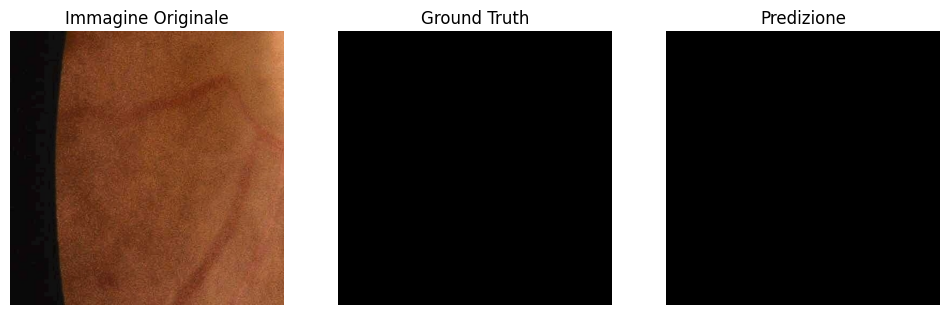

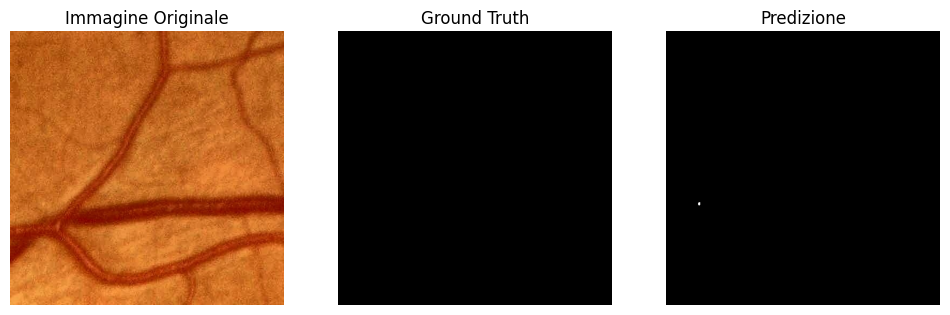

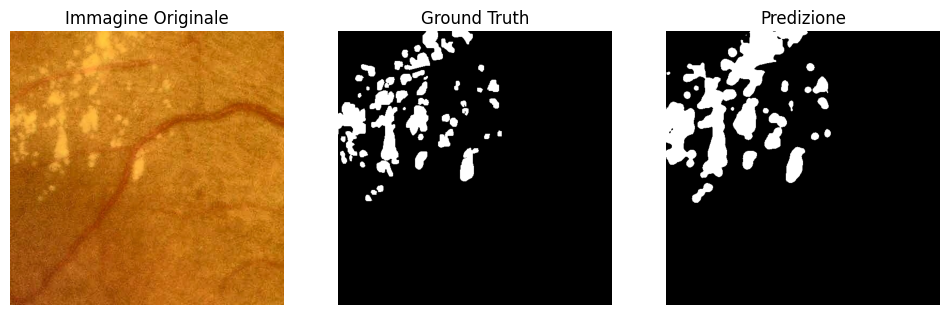

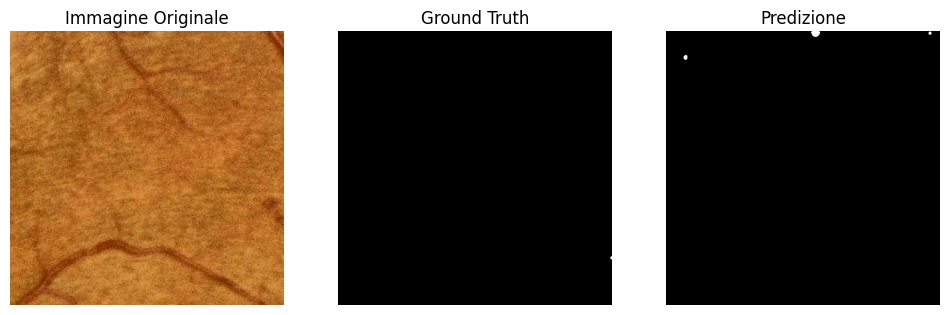

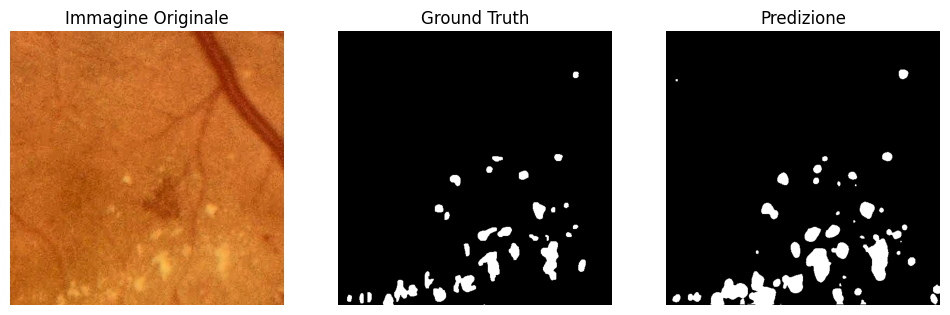

In [45]:
import matplotlib.pyplot as plt
model = UNet(in_channels=3, out_channels=1)
model.load_state_dict(torch.load("/kaggle/input/unet-weights-50/UNet_weights (2).pth", map_location=device,
                                weights_only = True))

def visualize_predictions(model, val_dataset, batch_size=32, num_images=5):
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    model.to(device)  # Move model to the correct device
    model.eval()
    
    images_shown = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            
            outputs = model(images)  # Ensure model is on the correct device
            predictions = torch.sigmoid(outputs) > 0.5  # Thresholding per ottenere la maschera binaria

            # Porta i tensori su CPU per la visualizzazione
            images = images.cpu().numpy().transpose(0, 2, 3, 1)  # Da (B, C, H, W) a (B, H, W, C)
            masks = masks.cpu().numpy().squeeze(1)  # Rimuove il canale extra (B, 1, H, W) → (B, H, W)
            predictions = predictions.cpu().numpy().squeeze(1)  # Stessa cosa per le predizioni

            # Visualizza le prime `num_images` immagini
            for i in range(min(num_images, images.shape[0])):
                fig, ax = plt.subplots(1, 3, figsize=(12, 4))

                # Immagine originale
                ax[0].imshow(images[i])
                ax[0].set_title("Immagine Originale")
                ax[0].axis("off")

                # Ground Truth
                ax[1].imshow(masks[i], cmap="gray")
                ax[1].set_title("Ground Truth")
                ax[1].axis("off")

                # Predizione del modello
                ax[2].imshow(predictions[i], cmap="gray")
                ax[2].set_title("Predizione")
                ax[2].axis("off")

                plt.show()
                
                images_shown += 1
                if images_shown >= num_images:
                    return  # Ferma la visualizzazione dopo `num_images` immagini

# Chiama la funzione dopo l'addestramento per vedere le predizioni
visualize_predictions(model, val_dataset, num_images=5)

## Evaluation on the test set

In [47]:
import os
import torch
import numpy as np
from torch.utils.data import DataLoader
import torchvision.transforms as T
import random

# 1) Lista di tutti i nomi di file patch di test
test_image_dir = "/kaggle/input/test-set/patches_test/patches_test"
test_mask_dir = "/kaggle/input/test-set/labels_test/labels_test"

test_filenames = os.listdir(test_image_dir)
test_filenames = sorted(test_filenames)

# 2) Crea il Dataset
final_transforms = T.Compose([
    T.Resize((512, 512))
])

test_dataset = SegmentationDataset(
    image_dir=test_image_dir,
    mask_dir=test_mask_dir,
    image_filenames=test_filenames,
    augmentations=None,
    transform=final_transforms
)

# 3) Crea il DataLoader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

In [48]:
import os
import numpy as np
import torch
from sklearn.metrics import average_precision_score

def evaluate_model(model, test_loader, threshold=0.5, eps=1e-7):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)
    
    # Inizializza contatori per le metriche
    test_total_tp = 0
    test_total_fp = 0
    test_total_fn = 0
    
    # Variabili per AUC-PR senza accumulo di tutti i dati
    aucpr_sum = 0
    num_batches = 0
    
    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device, dtype=torch.float16)   # [B, 3, H, W]
            masks = masks.to(device, dtype=torch.float16)     # [B, 1, H, W]

            # Abilita Mixed Precision con autocast
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)  # logits -> [B, 1, H, W]

            pred_probs = torch.sigmoid(outputs)  # [B, 1, H, W] in [0,1]
            
            # Binarizza le predizioni
            pred_bin = (pred_probs > threshold).float()

            # Flatten per metriche
            pred_bin_flat  = pred_bin.view(-1)
            masks_flat     = masks.view(-1)
            probs_flat     = pred_probs.view(-1)

            # Calcolo TP, FP, FN
            tp = (pred_bin_flat * masks_flat).sum().item()
            fp = (pred_bin_flat * (1 - masks_flat)).sum().item()
            fn = ((1 - pred_bin_flat) * masks_flat).sum().item()

            test_total_tp += tp
            test_total_fp += fp
            test_total_fn += fn

            # Calcolo AUC-PR per ogni batch senza accumulo di tutti i dati
            probs_np = probs_flat.float().cpu().numpy()
            masks_np = masks_flat.float().cpu().numpy()

            if np.sum(masks_np) > 0:  # Ensure at least one positive pixel
                batch_aucpr = average_precision_score(masks_np, probs_np)
                aucpr_sum += batch_aucpr
                num_batches += 1

            # Rilascia memoria dopo ogni batch
            del images, masks, outputs, pred_probs, pred_bin, pred_bin_flat, masks_flat, probs_flat, probs_np, masks_np
            torch.cuda.empty_cache()

    # Calcolo Precision, Recall, F1 su tutti i pixel
    test_precision = test_total_tp / (test_total_tp + test_total_fp + eps)
    test_recall    = test_total_tp / (test_total_tp + test_total_fn + eps)
    test_f1        = 2 * (test_precision * test_recall) / (test_precision + test_recall + eps)
    test_dice      = 2 * test_total_tp / (2 * test_total_tp + test_total_fp + test_total_fn + eps)

    # Calcolo AUC-PR medio
    test_aucpr = aucpr_sum / num_batches

    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall:    {test_recall:.4f}")
    print(f"Test F1:        {test_f1:.4f}")
    print(f"Test Dice:      {test_dice:.4f}")
    print(f"Test AUC-PR:    {test_aucpr:.4f}")

    # Svuota memoria GPU alla fine del test
    torch.cuda.empty_cache()

    return test_precision, test_recall, test_f1, test_dice, test_aucpr

In [49]:
unet_precision, unet_recall, unet_f1, unet_dice, unet_aucpr = evaluate_model(model,test_loader)

Test Precision: 0.6240
Test Recall:    0.9180
Test F1:        0.7429
Test Dice:      0.7429
Test AUC-PR:    0.7506


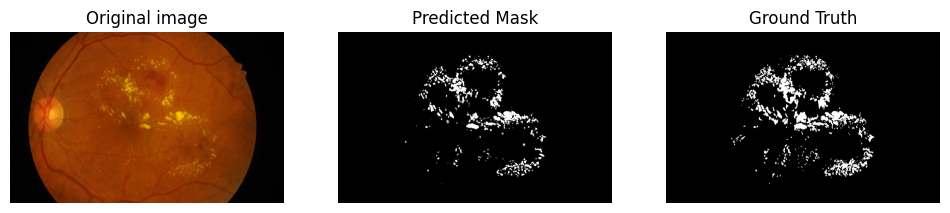

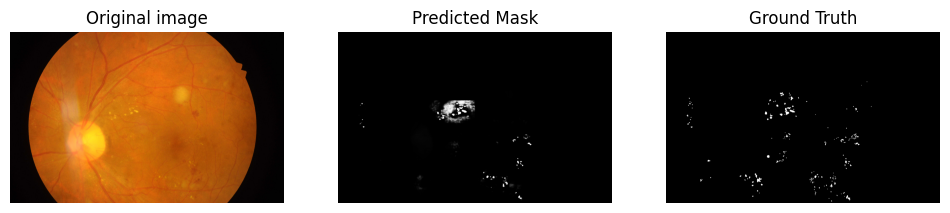

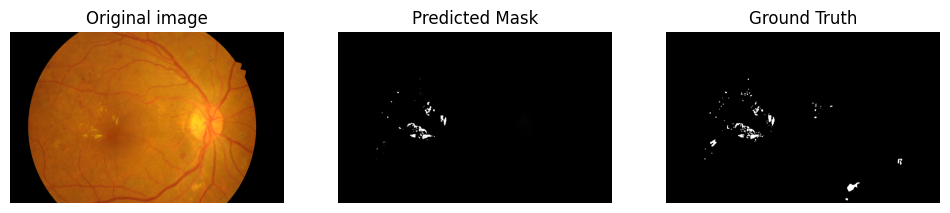

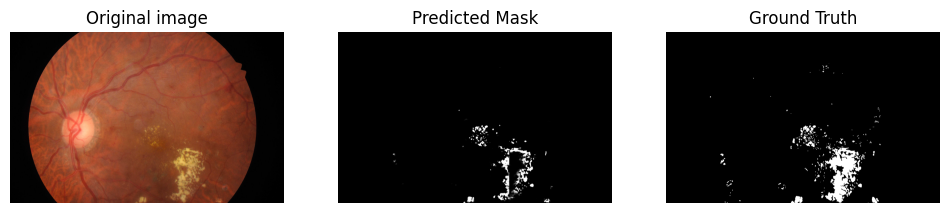

In [50]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# Imposta i percorsi
dir_test_img = "/kaggle/input/some-test-img/some/some_test_mask"  # Directory immagini test
dir_test_mask = "/kaggle/input/some-test-img/some/some_test_img"  # Dove salvare le maschere predette


# Parametri delle immagini
PATCH_SIZE = 512
IMAGE_WIDTH = 4288
IMAGE_HEIGHT = 2848

# Ridimensioniamo a un multiplo esatto di 512
CROP_WIDTH = (IMAGE_WIDTH // PATCH_SIZE) * PATCH_SIZE  # 4288 → 4096
CROP_HEIGHT = (IMAGE_HEIGHT // PATCH_SIZE) * PATCH_SIZE  # 2848 → 2560

# Carica il modello UNet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(in_channels=3, out_channels=1).to(device)
model.load_state_dict(torch.load("/kaggle/input/unet-weights3/UNet_weights (1).pth", map_location=device,
                                weights_only = True))
model.eval()

# Trasformazioni per PyTorch
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Seleziona immagini per la visualizzazione
test_images = sorted(os.listdir(dir_test_img))[:4]  # Seleziona le prime 4 immagini

for img_file in test_images:

    img_path = os.path.join(dir_test_img, img_file)
    mask_path = os.path.join(dir_test_mask, os.path.splitext(img_file)[0] + ".tif")


    img = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")  # Converti in scala di grigi

    # **Ritaglia l'immagine e la maschera alla dimensione 4096x2560**
    img = img.crop((0, 0, CROP_WIDTH, CROP_HEIGHT))
    mask = mask.crop((0, 0, CROP_WIDTH, CROP_HEIGHT))

    # Creazione array per ricostruire la maschera predetta
    pred_mask = np.zeros((CROP_HEIGHT, CROP_WIDTH), dtype=np.float32)

    # Loop per estrarre e inferire sulle patches
    for i in range(0, CROP_HEIGHT, PATCH_SIZE):
        for j in range(0, CROP_WIDTH, PATCH_SIZE):
            # Ritaglio della patch
            patch = img.crop((j, i, j + PATCH_SIZE, i + PATCH_SIZE))

            # Converte in tensor e invia alla GPU
            patch_tensor = transform(patch).unsqueeze(0).to(device)

            # Inferenza del modello
            with torch.no_grad():
                output = torch.sigmoid(model(patch_tensor))  # Sigmoid per valori tra [0,1]

            # Converti in numpy e rimuovi batch dimension
            pred_patch_np = output.squeeze().cpu().numpy()

            # Inserisci la patch nella maschera finale
            pred_mask[i:i + PATCH_SIZE, j:j + PATCH_SIZE] = pred_patch_np

    # Salva la maschera predetta
    pred_mask_img = Image.fromarray((pred_mask * 255).astype(np.uint8))  # Normalizza in [0,255]

    # Visualizzazione
    fig, ax = plt.subplots(1, 3, figsize=(12, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original image")
    ax[0].axis("off")

    ax[1].imshow(pred_mask, cmap="gray")
    ax[1].set_title("Predicted Mask")
    ax[1].axis("off")

    ax[2].imshow(mask, cmap="gray")
    ax[2].set_title("Ground Truth")
    ax[2].axis("off")

    plt.show()

## Other lesion masks

In [ ]:
def patchwise_custom_loss(y_pred, y_true, negative_mask, alpha=5):
    """
    Custom loss function for patch-based segmentation with lesion-guided attention.
    
    y_pred: Model predictions (logits)
    y_true: Ground truth hard exudate masks
    negative_mask: Areas occupied by other lesions (should be patch-aligned)
    alpha: Weight of the penalty term
    """
    # Compute Binary Cross Entropy Loss
    bce = F.binary_cross_entropy_with_logits(y_pred, y_true)

    # Compute penalty for false positives in negative mask areas
    penalty = alpha * (y_pred * negative_mask).mean()

    # Final loss
    return bce + penalty 

 # Construct the patch-aligned negative mask
negative_mask = torch.clamp(hemorrhage_patches + microaneurysm_patches + soft_exudate_patches, 0, 1)

In [25]:
#Vecchio dataset
import os
import numpy as np
import torch
from sklearn.metrics import average_precision_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Abilita il cuDNN auto-tuner per ottimizzare l'uso della memoria
torch.backends.cudnn.benchmark = True

# 1) Carica modello
model = UNet(in_channels=3, out_channels=1)
model.load_state_dict(torch.load("/kaggle/input/weights-unet2/unet_weights_2.pth", map_location=device, weights_only = True))
model.eval().to(device)

# Hyperparameters
threshold = 0.5
eps = 1e-7

# Inizializza contatori per le metriche
test_total_tp = 0
test_total_fp = 0
test_total_fn = 0

# Variabili per AUC-PR senza accumulo di tutti i dati
aucpr_sum = 0
num_batches = 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device, dtype=torch.float16)   # [B, 3, H, W]
        masks = masks.to(device, dtype=torch.float16)     # [B, 1, H, W]

        # Abilita Mixed Precision con autocast
        with torch.amp.autocast(device_type="cuda"):
            outputs = model(images)  # logits -> [B, 1, H, W]

        pred_probs = torch.sigmoid(outputs)  # [B, 1, H, W] in [0,1]
        
        # Binarizza le predizioni
        pred_bin = (pred_probs > threshold).float()

        # Flatten per metriche
        pred_bin_flat  = pred_bin.view(-1)
        masks_flat     = masks.view(-1)
        probs_flat     = pred_probs.view(-1)

        # Calcolo TP, FP, FN
        tp = (pred_bin_flat * masks_flat).sum().item()
        fp = (pred_bin_flat * (1 - masks_flat)).sum().item()
        fn = ((1 - pred_bin_flat) * masks_flat).sum().item()

        test_total_tp += tp
        test_total_fp += fp
        test_total_fn += fn

        # Calcolo AUC-PR per ogni batch senza accumulo di tutti i dati
        probs_np = probs_flat.float().cpu().numpy()
        masks_np = masks_flat.float().cpu().numpy()

        if np.sum(masks_np) > 0:  # Ensure at least one positive pixel
            batch_aucpr = average_precision_score(masks_np, probs_np)
            aucpr_sum += batch_aucpr
            num_batches += 1

        # Rilascia memoria dopo ogni batch
        del images, masks, outputs, pred_probs, pred_bin, pred_bin_flat, masks_flat, probs_flat, probs_np, masks_np
        torch.cuda.empty_cache()

# Calcolo Precision, Recall, F1 su tutti i pixel
test_precision = test_total_tp / (test_total_tp + test_total_fp + eps)
test_recall    = test_total_tp / (test_total_tp + test_total_fn + eps)
test_f1        = 2 * (test_precision * test_recall) / (test_precision + test_recall + eps)

# Calcolo AUC-PR medio
test_aucpr = aucpr_sum / num_batches

print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1:        {test_f1:.4f}")
print(f"Test AUC-PR:    {test_aucpr:.4f}")

# Svuota memoria GPU alla fine del test
torch.cuda.empty_cache()


Test Precision: 0.6763
Test Recall:    0.7834
Test F1:        0.7259
Test AUC-PR:    0.7228


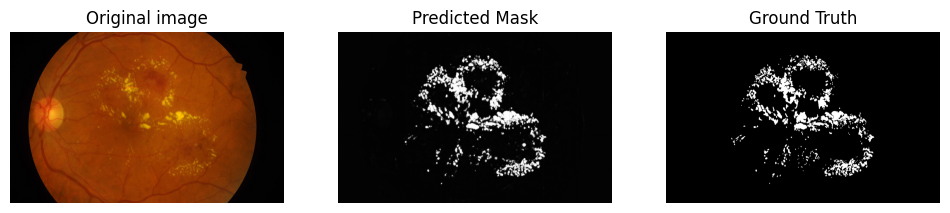

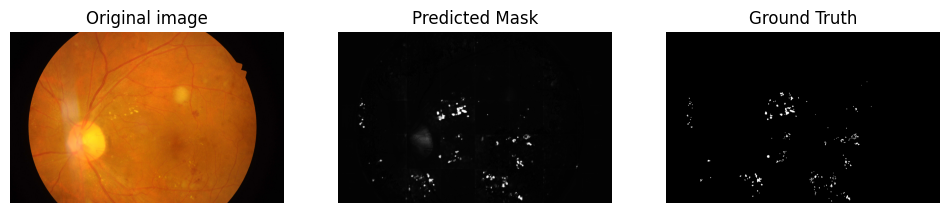

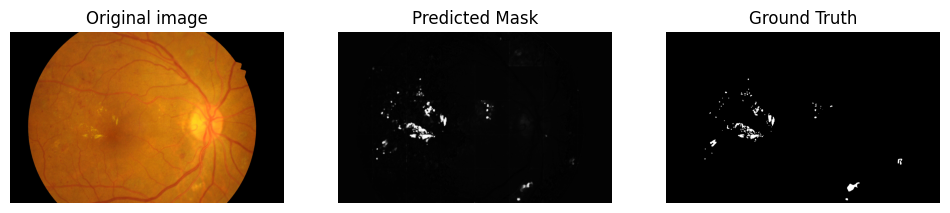

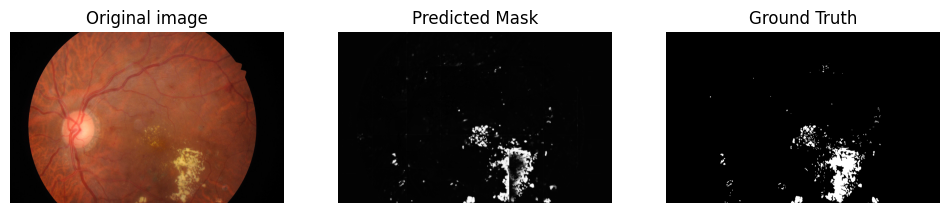

In [38]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# Imposta i percorsi
dir_test_img = "/kaggle/input/some-test-img/some/some_test_mask"  # Directory immagini test
dir_test_mask = "/kaggle/input/some-test-img/some/some_test_img"  # Dove salvare le maschere predette


# Creazione directory di output se non esiste
os.makedirs(output_test_pred, exist_ok=True)

# Parametri delle immagini
PATCH_SIZE = 512
IMAGE_WIDTH = 4288
IMAGE_HEIGHT = 2848

# Ridimensioniamo a un multiplo esatto di 512
CROP_WIDTH = (IMAGE_WIDTH // PATCH_SIZE) * PATCH_SIZE  # 4288 → 4096
CROP_HEIGHT = (IMAGE_HEIGHT // PATCH_SIZE) * PATCH_SIZE  # 2848 → 2560

# Carica il modello UNet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(in_channels=3, out_channels=1).to(device)
model.load_state_dict(torch.load("/kaggle/input/weights-unet2/unet_weights_2.pth", map_location=device,
                                weights_only = True))
model.eval()

# Trasformazioni per PyTorch
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Seleziona immagini per la visualizzazione
test_images = sorted(os.listdir(dir_test_img))[:4]  # Seleziona le prime 4 immagini

for img_file in test_images:

    img_path = os.path.join(dir_test_img, img_file)
    mask_path = os.path.join(dir_test_mask, os.path.splitext(img_file)[0] + ".tif")


    img = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")  # Converti in scala di grigi

    # **Ritaglia l'immagine e la maschera alla dimensione 4096x2560**
    img = img.crop((0, 0, CROP_WIDTH, CROP_HEIGHT))
    mask = mask.crop((0, 0, CROP_WIDTH, CROP_HEIGHT))

    # Creazione array per ricostruire la maschera predetta
    pred_mask = np.zeros((CROP_HEIGHT, CROP_WIDTH), dtype=np.float32)

    # Loop per estrarre e inferire sulle patches
    for i in range(0, CROP_HEIGHT, PATCH_SIZE):
        for j in range(0, CROP_WIDTH, PATCH_SIZE):
            # Ritaglio della patch
            patch = img.crop((j, i, j + PATCH_SIZE, i + PATCH_SIZE))

            # Converte in tensor e invia alla GPU
            patch_tensor = transform(patch).unsqueeze(0).to(device)

            # Inferenza del modello
            with torch.no_grad():
                output = torch.sigmoid(model(patch_tensor))  # Sigmoid per valori tra [0,1]

            # Converti in numpy e rimuovi batch dimension
            pred_patch_np = output.squeeze().cpu().numpy()

            # Inserisci la patch nella maschera finale
            pred_mask[i:i + PATCH_SIZE, j:j + PATCH_SIZE] = pred_patch_np

    # Salva la maschera predetta
    pred_mask_img = Image.fromarray((pred_mask * 255).astype(np.uint8))  # Normalizza in [0,255]

    # Visualizzazione
    fig, ax = plt.subplots(1, 3, figsize=(12, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original image")
    ax[0].axis("off")

    ax[1].imshow(pred_mask, cmap="gray")
    ax[1].set_title("Predicted Mask")
    ax[1].axis("off")

    ax[2].imshow(mask, cmap="gray")
    ax[2].set_title("Ground Truth")
    ax[2].axis("off")

    plt.show()


## SeGAN : Segmentation Adversarial Network

In [10]:
#Model definition: Segmentor and Critic
import torch.nn as nn
import torch.nn.functional as F
import torch
from numpy.random import normal
from math import sqrt
import argparse

channel_dim = 3
ndf = 64

class GlobalConvBlock(nn.Module):
    def __init__(self, in_dim, out_dim, kernel_size):
        super(GlobalConvBlock, self).__init__()
        pad0 = (kernel_size[0] - 1) / 2
        pad1 = (kernel_size[1] - 1) / 2

        self.conv_l1 = nn.Conv2d(in_dim, out_dim, kernel_size=(kernel_size[0], 1),
                                 padding=(pad0, 0))
        self.conv_l2 = nn.Conv2d(out_dim, out_dim, kernel_size=(1, kernel_size[1]),
                                 padding=(0, pad1))
        self.conv_r1 = nn.Conv2d(in_dim, out_dim, kernel_size=(1, kernel_size[1]),
                                 padding=(0, pad1))
        self.conv_r2 = nn.Conv2d(out_dim, out_dim, kernel_size=(kernel_size[0], 1),
                                 padding=(pad0, 0))
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.normal_(1.0, 0.02)
                m.bias.data.fill_(0)

    def forward(self, x):
        x_l = self.conv_l1(x)
        x_l = self.conv_l2(x_l)
        x_r = self.conv_r1(x)
        x_r = self.conv_r2(x_r)
        #combine two paths
        x = x_l + x_r
        return x

class ResidualBlock(nn.Module):
    def __init__(self, indim):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(indim, indim*2, kernel_size=1, bias=False)
        self.norm1 = nn.BatchNorm2d(indim*2)
        self.relu1 = nn.LeakyReLU(0.2, inplace=True)
        self.conv2 = nn.Conv2d(indim*2, indim*2, kernel_size=3, padding=1, bias=False)
        self.norm2 = nn.BatchNorm2d(indim*2)
        self.relu2 = nn.LeakyReLU(0.2, inplace=True)
        self.conv3 = nn.Conv2d(indim*2, indim, kernel_size=1, bias=False)
        self.norm3 = nn.BatchNorm2d(indim)
        self.relu3 = nn.LeakyReLU(0.2, inplace=True)
        #parameter initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.normal_(1.0, 0.02)
                m.bias.data.fill_(0)

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.relu1(residual)
        residual = self.conv2(residual)
        residual = self.relu2(residual)
        residual = self.conv3(residual)
        residual = self.relu3(residual)
        out = x + residual
        return out

class ResidualBlock_D(nn.Module):
    def __init__(self, indim):
        super(ResidualBlock_D, self).__init__()
        self.conv1 = nn.Conv2d(indim, indim*2, kernel_size=1, bias=False)
        self.norm1 = nn.BatchNorm2d(indim*2)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(indim*2, indim*2, kernel_size=3, padding=1, bias=False)
        self.norm2 = nn.BatchNorm2d(indim*2)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv3 = nn.Conv2d(indim*2, indim, kernel_size=1, bias=False)
        self.norm3 = nn.BatchNorm2d(indim)
        self.relu3 = nn.ReLU(inplace=True)
        #parameter initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.normal_(1.0, 0.02)
                m.bias.data.fill_(0)

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.relu1(residual)
        residual = self.conv2(residual)
        residual = self.relu2(residual)
        residual = self.conv3(residual)
        residual = self.relu3(residual)
        out = x + residual
        return out


class NetS(nn.Module):
    def __init__(self, ngpu):
        super(NetS, self).__init__()
        self.ngpu = ngpu
        self.convblock1 = nn.Sequential(
            # input is (channel_dim) x 128 x 128
            nn.Conv2d(channel_dim, ndf, 7, 2, 3, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 64 x 64
        )
        self.convblock1_1 = ResidualBlock(ndf)
        self.convblock2 = nn.Sequential(
            # state size. (ndf) x 64 x 64
            nn.Conv2d(ndf, ndf * 2, 5, 2, 2, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 32 x 32
        )
        self.convblock2_1 = ResidualBlock(ndf*2)
        self.convblock3 = nn.Sequential(
            # state size. (ndf*2) x 32 x 32
            nn.Conv2d(ndf * 2, ndf * 4, 5, 2, 2, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 16 x 16
        )
        self.convblock3_1 = ResidualBlock(ndf*4)
        self.convblock4 = nn.Sequential(
            # state size. (ndf*4) x 16 x 16
            nn.Conv2d(ndf * 4, ndf * 8, 5, 2, 2, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 8 x 8
        )
        self.convblock4_1 = ResidualBlock(ndf*8)
        self.convblock5 = nn.Sequential(
            # state size. (ndf*8) x 8 x 8
            nn.Conv2d(ndf * 8, ndf * 8, 5, 2, 2, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 4 x 4
        )
        self.convblock5_1 = ResidualBlock(ndf*8)
        self.convblock6 = nn.Sequential(
            # state size. (ndf*8) x 4 x 4
            nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*16) x 2 x 2
        )
        self.convblock6_1 = nn.Sequential(
            # state size. (ndf*16) x 2 x 2
            nn.Conv2d(ndf * 16, ndf * 16, kernel_size=1, bias=False),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*16) x 2 x 2
        )
        self.convblock7 = nn.Sequential(
            # state size. (ndf*16) x 2 x 2
            nn.Conv2d(ndf * 16, ndf * 32, 3, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 32),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*32) x 1 x 1
        )
        # self.convblock7_1 = ResidualBlock(ndf*32)
        self.convblock8 = nn.Sequential(
            # state size. (ndf*32) x 1 x 1
            nn.Conv2d(ndf * 32, ndf * 8, kernel_size=1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 1 x 1
        )


        self.deconvblock1 = nn.Sequential(
            # state size. (ngf*8) x 1 x 1
            nn.ConvTranspose2d(ndf * 8, ndf * 32, kernel_size=1, bias=False),
            nn.BatchNorm2d(ndf * 32),
            nn.ReLU(True),
            # state size. (ngf*32) x 1 x 1
        )
        self.deconvblock2 = nn.Sequential(
            # state size. (cat: ngf*32) x 1 x 1
            nn.Conv2d(ndf * 64 , ndf * 16, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ndf * 16),
            nn.ReLU(True),
            # state size. (ngf*16) x 2 x 2
        )
        self.deconvblock2_1 = nn.Sequential(
            # state size. (ndf*16) x 2 x 2
            nn.Conv2d(ndf * 16, ndf * 16, kernel_size=1, bias=False),
            nn.BatchNorm2d(ndf * 16),
            nn.ReLU(inplace=True),
            # state size. (ndf*16) x 2 x 2
        )
        self.deconvblock3 = nn.Sequential(
            # state size. (cat: ngf*16) x 2 x 2
            nn.Conv2d(ndf * 16 * 2, ndf * 8, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
        )
        self.deconvblock3_1 = ResidualBlock_D(ndf*8)
        self.deconvblock4 = nn.Sequential(
            # state size. (ngf*8) x 4 x 4
            GlobalConvBlock(ndf*8*2, ndf*8, (7, 7)),
            # nn.ConvTranspose2d(ndf * 8 * 2, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 8 x 8
        )
        self.deconvblock4_1 = ResidualBlock_D(ndf*8)
        self.deconvblock5 = nn.Sequential(
            # state size. (ngf*8) x 8 x 8
            GlobalConvBlock(ndf*8*2, ndf*4, (7, 7)),
            # nn.ConvTranspose2d(ndf * 8 * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 16 x 16
        )
        self.deconvblock5_1 = ResidualBlock_D(ndf*4)
        self.deconvblock6 = nn.Sequential(
            # state size. (ngf*4) x 16 x 16
            GlobalConvBlock(ndf*4*2, ndf*2, (9, 9)),
            # nn.ConvTranspose2d(ndf * 4 * 2, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 32 x 32
        )
        self.deconvblock6_1 = ResidualBlock_D(ndf*2)
        self.deconvblock7 = nn.Sequential(
            # state size. (ngf*2) x 32 x 32
            GlobalConvBlock(ndf*2*2, ndf, (9, 9)),
            # nn.ConvTranspose2d(ndf * 2 * 2,     ndf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf),
            nn.ReLU(True),
            # state size. (ngf) x 64 x 64
        )
        self.deconvblock7_1 = ResidualBlock_D(ndf)
        self.deconvblock8 = nn.Sequential(
            # state size. (ngf) x 64 x 64
            GlobalConvBlock(ndf*2, ndf, (11, 11)),
            # nn.ConvTranspose2d( ndf * 2, ndf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf),
            nn.ReLU(True),
            # state size. (ngf) x 128 x 128
        )
        self.deconvblock8_1 = ResidualBlock_D(ndf)
        self.deconvblock9 = nn.Sequential(
            # state size. (ngf) x 128 x 128
            nn.Conv2d( ndf, 1, 5, 1, 2, bias=False),
            # state size. (channel_dim) x 128 x 128
            # nn.Sigmoid()
        )

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.normal_(1.0, 0.02)
                m.bias.data.zero_()
            elif isinstance(m, nn.ConvTranspose2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()


    def forward(self, input):
        # for now it only supports one GPU
        if isinstance(input.data, torch.cuda.FloatTensor):
            encoder1 = self.convblock1(input)
            encoder1 = self.convblock1_1(encoder1)
            encoder2 = self.convblock2(encoder1)
            encoder2 = self.convblock2_1(encoder2)
            encoder3 = self.convblock3(encoder2)
            encoder3 = self.convblock3_1(encoder3)
            encoder4 = self.convblock4(encoder3)
            encoder4 = self.convblock4_1(encoder4)
            encoder5 = self.convblock5(encoder4)
            encoder5 = self.convblock5_1(encoder5)
            encoder6 = self.convblock6(encoder5)
            encoder6 = self.convblock6_1(encoder6) + encoder6
            encoder7 = self.convblock7(encoder6)
            encoder8 = self.convblock8(encoder7)

            decoder1 = self.deconvblock1(encoder8)
            decoder1 = torch.cat([encoder7,decoder1],1)
            decoder1 = F.upsample(decoder1, size = encoder6.size()[2:], mode='bilinear')
            decoder2 = self.deconvblock2(decoder1)
            decoder2 = self.deconvblock2_1(decoder2) + decoder2
            # concatenate along depth dimension
            decoder2 = torch.cat([encoder6,decoder2],1)
            decoder2 = F.upsample(decoder2, size = encoder5.size()[2:], mode='bilinear')
            decoder3 = self.deconvblock3(decoder2)
            decoder3 = self.deconvblock3_1(decoder3)
            decoder3 = torch.cat([encoder5,decoder3],1)
            decoder3 = F.upsample(decoder3, size = encoder4.size()[2:], mode='bilinear')
            decoder4 = self.deconvblock4(decoder3)
            decoder4 = self.deconvblock4_1(decoder4)
            decoder4 = torch.cat([encoder4,decoder4],1)
            decoder4 = F.upsample(decoder4, size = encoder3.size()[2:], mode='bilinear')
            decoder5 = self.deconvblock5(decoder4)
            decoder5 = self.deconvblock5_1(decoder5)
            decoder5 = torch.cat([encoder3,decoder5],1)
            decoder5 = F.upsample(decoder5, size = encoder2.size()[2:], mode='bilinear')
            decoder6 = self.deconvblock6(decoder5)
            decoder6 = self.deconvblock6_1(decoder6)
            decoder6 = torch.cat([encoder2,decoder6],1)
            decoder6 = F.upsample(decoder6, size = encoder1.size()[2:], mode='bilinear')
            decoder7 = self.deconvblock7(decoder6)
            decoder7 = self.deconvblock7_1(decoder7)
            decoder7 = torch.cat([encoder1,decoder7],1)
            decoder7 = F.upsample(decoder7, size = input.size()[2:], mode='bilinear')
            decoder8 = self.deconvblock8(decoder7)
            decoder8 = self.deconvblock8_1(decoder8)
            decoder9 = self.deconvblock9(decoder8)
        
        return decoder9



class NetC(nn.Module):
    def __init__(self, ngpu):
        super(NetC, self).__init__()
        self.ngpu = ngpu
        self.convblock1 = nn.Sequential(
            # input is (channel_dim) x 128 x 128
            nn.Conv2d(channel_dim, ndf, 7, 2, 3, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # nn.Dropout2d(p=0.2),
            # state size. (ndf) x 64 x 64
        )
        self.convblock1_1 = nn.Sequential(
            # state size. (ndf) x 64 x 64
            GlobalConvBlock(ndf, ndf * 2, (13, 13)),
            # nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # nn.Dropout2d(p=0.2),
            # state size. (ndf*2) x 64 x 64
        )
        self.convblock2 = nn.Sequential(
            # state size. (ndf * 2) x 64 x 64
            nn.Conv2d(ndf * 1, ndf * 2, 5, 2, 2, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # nn.Dropout2d(p=0.2),
            # state size. (ndf*2) x 32 x 32
        )
        self.convblock2_1 = nn.Sequential(
            # input is (ndf*2) x 32 x 32
            GlobalConvBlock(ndf * 2, ndf * 4, (11, 11)),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # nn.Dropout2d(p=0.2),
            # state size. (ndf*4) x 32 x 32
        )
        self.convblock3 = nn.Sequential(
            # state size. (ndf * 4) x 32 x 32
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # nn.Dropout2d(p=0.2),
            # state size. (ndf*4) x 16 x 16
        )
        self.convblock3_1 = nn.Sequential(
            # input is (ndf*4) x 16 x 16
            GlobalConvBlock(ndf * 4, ndf * 8, (9, 9)),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # nn.Dropout2d(p=0.2),
            # state size. (ndf * 8) x 16 x 16
        )
        self.convblock4 = nn.Sequential(
            # state size. (ndf*4) x 16 x 16
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # nn.Dropout2d(p=0.2),
            # state size. (ndf*8) x 8 x 8
        )
        self.convblock4_1 = nn.Sequential(
            # input is (ndf*8) x 8 x 8
            GlobalConvBlock(ndf * 8, ndf * 16, (7, 7)),
            nn.BatchNorm2d(ndf * 16),
            nn.LeakyReLU(0.2, inplace=True),
            # nn.Dropout2d(p=0.2),
            # state size. (ndf*16) x 8 x 8
        )
        self.convblock5 = nn.Sequential(
            # state size. (ndf*8) x 8 x 8
            nn.Conv2d(ndf * 8, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # nn.Dropout2d(p=0.2),
            # state size. (ndf*16) x 4 x 4
        )
        self.convblock5_1 = nn.Sequential(
            # input is (ndf*16) x 4 x 4
            nn.Conv2d(ndf * 16, ndf * 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ndf * 32),
            nn.LeakyReLU(0.2, inplace=True),
            # nn.Dropout2d(p=0.2),
            # state size. (ndf*32) x 4 x 4
        )
        self.convblock6 = nn.Sequential(
            # state size. (ndf*32) x 4 x 4
            nn.Conv2d(ndf * 8, ndf * 8, 3, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # nn.Dropout2d(p=0.2),
            # state size. (ndf*32) x 2 x 2
        )
        # self._initialize_weights()
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.normal_(1.0, 0.02)
                m.bias.data.zero_()

    def forward(self, input):
        if isinstance(input.data, torch.cuda.FloatTensor):
            batchsize = input.size()[0]
            out1 = self.convblock1(input)
            # out1 = self.convblock1_1(out1)
            out2 = self.convblock2(out1)
            # out2 = self.convblock2_1(out2)
            out3 = self.convblock3(out2)
            # out3 = self.convblock3_1(out3)
            out4 = self.convblock4(out3)
            # out4 = self.convblock4_1(out4)
            out5 = self.convblock5(out4)
            # out5 = self.convblock5_1(out5)
            out6 = self.convblock6(out5)
            # out6 = self.convblock6_1(out6) + out6
            output = torch.cat((input.view(batchsize,-1),1*out1.view(batchsize,-1),
                                2*out2.view(batchsize,-1),2*out3.view(batchsize,-1),
                                2*out4.view(batchsize,-1),2*out5.view(batchsize,-1),
                                4*out6.view(batchsize,-1)),1)
        return output

In [ ]:
from __future__ import print_function
import argparse
import os
import gc
import numpy as np
from PIL import Image
import torch
from torch.utils import data
import torch.backends.cudnn as cudnn
import torch.optim as optim
from torch import nn
import torchvision.utils as vutils
from torch.autograd import Variable
import torch.nn.functional as F


# Impostazioni manuali per l'addestramento
BATCH_SIZE = 36
N_EPOCHS = 20
LEARNING_RATE = 0.0002
NGPU = 1
BETA1 = 0.5
DECAY = 0.5
USE_CUDA = torch.cuda.is_available()
SEED = 666

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)


def dice_loss(input, target):
    num = input * target
    num = torch.sum(num, dim=(2, 3))
    den1 = torch.sum(input * input, dim=(2, 3))
    den2 = torch.sum(target * target, dim=(2, 3))
    dice = 2 * (num / (den1 + den2))
    dice_total = 1 - torch.sum(dice) / dice.size(0)  # Media sulla batch size
    return dice_total

# Configurazione CUDA
torch.manual_seed(SEED)
if USE_CUDA:
    torch.cuda.manual_seed(SEED)
cudnn.benchmark = True

# Creazione dei modelli
netS = NetS(ngpu=NGPU)
netC = NetC(ngpu=NGPU)

if USE_CUDA:
    netS = netS.cuda()
    netC = netC.cuda()

# Definizione degli ottimizzatori
optimizerG = optim.Adam(netS.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
optimizerD = optim.Adam(netC.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))

max_iou = 0
netS.train()

# GradScaler per Mixed Precision
scaler = torch.cuda.amp.GradScaler()

torch.cuda.empty_cache()
gc.collect()

for epoch in range(N_EPOCHS):
    for i, data in enumerate(train_loader, 1):
        torch.cuda.empty_cache()
        gc.collect()
        
        netC.zero_grad()
        input, label = data[0].cuda(non_blocking=True), data[1].cuda(non_blocking=True)
        
        label = label.type(torch.FloatTensor).cuda()
        with torch.cuda.amp.autocast():
            output = torch.sigmoid(netS(input)).detach()
            del input  # Libera memoria
            gc.collect()
            
            output_masked = label.clone()
            for d in range(3):
                output_masked[:, d, :, :] = label[:, d, :, :].unsqueeze(1) * output
            
            result = netC(output_masked.cuda())
            target_D = netC(label.cuda())
            loss_D = - torch.mean(torch.abs(result - target_D))
            del output, output_masked, result, target_D  # Libera memoria
            gc.collect()
        
        scaler.scale(loss_D).backward()
        scaler.step(optimizerD)
        scaler.update()
        
        for p in netC.parameters():
            p.data.clamp_(-0.05, 0.05)
        
        netS.zero_grad()
        with torch.cuda.amp.autocast():
            output = torch.sigmoid(netS(label))
            result = netC(output.cuda())
            loss_dice = dice_loss(output, label)
            loss_G = torch.mean(torch.abs(result - label))
            loss_G_joint = loss_G + loss_dice
            del output, result  # Libera memoria
            gc.collect()
        
        scaler.scale(loss_G_joint).backward()
        scaler.step(optimizerG)
        scaler.update()
    
    print(f"Epoch[{epoch}]({i}/{len(train_loader)}): Dice: {1 - loss_dice.item():.4f}, G_Loss: {loss_G.item():.4f}, D_Loss: {loss_D.item():.4f}")
    torch.cuda.memory_summary(device=None, abbreviated=False)  # Monitora l'uso della memoria
    
    if epoch % 10 == 0:
        netS.eval()
        IoUs, dices = [], []
        with torch.no_grad():
            for i, data in enumerate(val_loader, 1):
                input, gt = data[0].cuda(non_blocking=True), data[1].cuda(non_blocking=True)
                pred = netS(input)
                pred = (pred >= 0.5).type(torch.LongTensor)
                pred_np = pred.cpu().numpy()
                gt_np = gt.cpu().numpy()
                for x in range(input.size(0)):
                    IoU = np.sum(pred_np[x][gt_np[x] == 1]) / float(np.sum(pred_np[x]) + np.sum(gt_np[x]) - np.sum(pred_np[x][gt_np[x] == 1]))
                    dice = 2 * np.sum(pred_np[x][gt_np[x] == 1]) / float(np.sum(pred_np[x]) + np.sum(gt_np[x]))
                    IoUs.append(IoU)
                    dices.append(dice)
        
        netS.train()
        mIoU = np.mean(IoUs)
        mdice = np.mean(dices)
        print(f'mIoU: {mIoU:.4f}, Dice: {mdice:.4f}')
        
        if mIoU > max_iou:
            max_iou = mIoU
            torch.save(netS.state_dict(), f'{OUT_PATH}/NetS_epoch_{epoch}.pth')

        
  #  if epoch % 25 == 0:
  #      LEARNING_RATE *= DECAY
  #      LEARNING_RATE = max(LEARNING_RATE, 1e-8)
  #      print(f'Learning Rate: {LEARNING_RATE:.6f}, Max mIoU: {max_iou:.4f}')
  #      optimizerG = optim.Adam(netS.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
  #      optimizerD = optim.Adam(netC.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))


## Swin UNETR

In [ ]:
# Esempio con un modello SwinUNETR
from monai.networks.nets import SwinUNETR

# 📌 Inizializza il modello
model = SwinUNETR(
    img_size=(512, 512),  
    in_channels=3,  
    out_channels=1,  
    feature_size=48,  
    spatial_dims=2  
)

# 📌 Allenamento
train_losses, val_losses, val_auprs = train_model(
    model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size = 4,
    num_epochs=20,
    lr=1e-4
)

📌 Training su: cuda


<ipython-input-12-39e1d18f9b0d>:56: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # Mixed precision training


📌 Epoch 1/20 | Train Loss: 0.1720 | Val Loss: 0.0846 | Val AUPR: 0.6819
✅ Miglior modello salvato!
📌 Epoch 2/20 | Train Loss: 0.0891 | Val Loss: 0.0787 | Val AUPR: 0.7524
✅ Miglior modello salvato!
📌 Epoch 3/20 | Train Loss: 0.0766 | Val Loss: 0.0612 | Val AUPR: 0.7577
✅ Miglior modello salvato!
📌 Epoch 4/20 | Train Loss: 0.0623 | Val Loss: 0.0634 | Val AUPR: 0.7511
📌 Epoch 5/20 | Train Loss: 0.0592 | Val Loss: 0.0483 | Val AUPR: 0.8142
✅ Miglior modello salvato!


## Lesion mask combination

In [77]:
#batch size 32 e 50 epoche
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from torch.cuda.amp import autocast, GradScaler

# Enable cuDNN auto-tuner for potential speed-up
torch.backends.cudnn.benchmark = True

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Weighted Binary Cross Entropy Loss ===
class WeightedBCELoss(nn.Module):
    def __init__(self, pos_weight=8):
        super(WeightedBCELoss, self).__init__()
        # Make sure pos_weight is on the same device as your model
        self.pos_weight = torch.tensor(pos_weight, device=device)  
    
    def forward(self, y_pred, y_true):
        # y_pred should be logits for binary_cross_entropy_with_logits
        return F.binary_cross_entropy_with_logits(y_pred, y_true, pos_weight=self.pos_weight)

# === Training Function ===
def main():
    print("Using device:", device)

    # Hyperparameters
    num_epochs = 100
    batch_size = 8
    learning_rate = 1e-4
    eps = 1e-7
    threshold = 0.5

    # Initialize model, loss, optimizer
    model = UNet(in_channels=3, out_channels=1).to(device)
    criterion = WeightedBCELoss()  # Weighted BCE
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.1)

    # Initialize GradScaler for Mixed Precision
    scaler = torch.amp.GradScaler()

    for epoch in range(num_epochs):
        model.train()
        
        # Tracking variables for training
        train_loss = 0.0
        train_total_tp = 0.0
        train_total_fp = 0.0
        train_total_fn = 0.0

        # === Training Loop ===
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            
            # Forward pass under mixed precision
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, masks)

            # Backward pass with scaled gradients
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            # Accumulate train loss
            train_loss += loss.item()

            # Accumulate TP, FP, FN for metrics (with no grad needed)
            with torch.no_grad():
                # Sigmoid to get probabilities
                y_pred = torch.sigmoid(outputs)
                
                # Binarize predictions and ground truths
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()

                # Summation over all pixels in the batch
                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()

                train_total_tp += tp.item()
                train_total_fp += fp.item()
                train_total_fn += fn.item()

        # Compute average training loss
        train_loss /= len(train_loader)
        
        # Compute precision and recall across the entire epoch
        train_precision = train_total_tp / (train_total_tp + train_total_fp + eps)
        train_recall = train_total_tp / (train_total_tp + train_total_fn + eps)

        # === Validation Loop ===
        model.eval()
        
        val_loss = 0.0
        val_total_tp = 0.0
        val_total_fp = 0.0
        val_total_fn = 0.0
        
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)

                # Forward pass under mixed precision
                with torch.amp.autocast(device_type="cuda"):
                    outputs = model(images)
                    loss = criterion(outputs, masks)

                # Accumulate validation loss
                val_loss += loss.item()

                # Accumulate TP, FP, FN for metrics
                y_pred = torch.sigmoid(outputs)
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()

                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()

                val_total_tp += tp.item()
                val_total_fp += fp.item()
                val_total_fn += fn.item()

        # Compute average validation loss
        val_loss /= len(val_loader)

        # Compute precision and recall for validation set
        val_precision = val_total_tp / (val_total_tp + val_total_fp + eps)
        val_recall = val_total_tp / (val_total_tp + val_total_fn + eps)

        # Print epoch results
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Train Precision: {train_precision:.4f} | Train Recall: {train_recall:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Precision: {val_precision:.4f} | Val Recall: {val_recall:.4f}")

    print("Training complete!")
    # Save model checkpoint
    torch.save(model.state_dict(), "unet_segmentation.pth")
    print("Model saved successfully!")

# === Entry Point ===
if __name__ == "__main__":
    main()


Using device: cuda
Epoch 1/100 | Train Loss: 0.6951 | Train Precision: 0.0213 | Train Recall: 0.5205 | Val Loss: 0.6165 | Val Precision: 0.0582 | Val Recall: 0.2256
Epoch 2/100 | Train Loss: 0.5614 | Train Precision: 0.1258 | Train Recall: 0.3822 | Val Loss: 0.5122 | Val Precision: 0.3276 | Val Recall: 0.5902
Epoch 3/100 | Train Loss: 0.4905 | Train Precision: 0.2191 | Train Recall: 0.5890 | Val Loss: 0.4612 | Val Precision: 0.3689 | Val Recall: 0.6745
Epoch 4/100 | Train Loss: 0.4492 | Train Precision: 0.2760 | Train Recall: 0.6410 | Val Loss: 0.4423 | Val Precision: 0.5042 | Val Recall: 0.4736
Epoch 5/100 | Train Loss: 0.4178 | Train Precision: 0.2643 | Train Recall: 0.6678 | Val Loss: 0.4065 | Val Precision: 0.2490 | Val Recall: 0.7715
Epoch 6/100 | Train Loss: 0.3865 | Train Precision: 0.2993 | Train Recall: 0.7007 | Val Loss: 0.4034 | Val Precision: 0.1609 | Val Recall: 0.8847
Epoch 7/100 | Train Loss: 0.3623 | Train Precision: 0.2960 | Train Recall: 0.7164 | Val Loss: 0.3547 | Va

KeyboardInterrupt: 

In [9]:
#batch 32 e weight_decay=1e-4 (modello di cui purtroppo non ha salvato i pesi)
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from torch.cuda.amp import autocast, GradScaler

# Librerie aggiuntive per metriche
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Enable cuDNN auto-tuner
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class WeightedBCELoss(nn.Module):
    def __init__(self, pos_weight=8):
        super(WeightedBCELoss, self).__init__()
        self.pos_weight = torch.tensor(pos_weight, device=device)
    
    def forward(self, y_pred, y_true):
        return F.binary_cross_entropy_with_logits(y_pred, y_true, pos_weight=self.pos_weight)

def main():
    print("Using device:", device)

    # Hyperparameters
    num_epochs = 20
    learning_rate = 1e-4
    eps = 1e-7
    threshold = 0.5

    # Inizializza model, loss, optimizer
    model = UNet(in_channels=3, out_channels=1).to(device)
    criterion = WeightedBCELoss(pos_weight=8)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    # GradScaler per Mixed Precision
    scaler = torch.amp.GradScaler()

    # Lists to store loss and AUPR values
    train_losses = []
    val_losses = []
    train_f1_scores = []
    val_auprs = []
    val_f1_scores = []
    
    for epoch in range(num_epochs):
        model.train()
        
        train_loss = 0.0
        train_total_tp = 0.0
        train_total_fp = 0.0
        train_total_fn = 0.0
    
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
    
            optimizer.zero_grad()
            
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, masks)
    
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
    
            train_loss += loss.item()
    
            # Binarized metrics
            with torch.no_grad():
                y_pred = torch.sigmoid(outputs)
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()
    
                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()
    
                train_total_tp += tp.item()
                train_total_fp += fp.item()
                train_total_fn += fn.item()
    
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
    
        train_precision = train_total_tp / (train_total_tp + train_total_fp + eps)
        train_recall = train_total_tp / (train_total_tp + train_total_fn + eps)
        train_f1 = 2 * (train_precision * train_recall) / (train_precision + train_recall + eps)
        train_f1_scores.append(train_f1)
    
        # --- Validation Loop ---
        model.eval()
        val_loss = 0.0
        all_val_probs = []
        all_val_targets = []
        
        val_total_tp = 0.0
        val_total_fp = 0.0
        val_total_fn = 0.0
    
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
    
                with torch.amp.autocast(device_type="cuda"):
                    outputs = model(images)
                    loss = criterion(outputs, masks)
    
                val_loss += loss.item()
    
                y_pred = torch.sigmoid(outputs)
                all_val_probs.append(y_pred.cpu().numpy().astype(np.float16).ravel())
                all_val_targets.append(masks.cpu().numpy().astype(np.float16).ravel())
    
                # Binarized metrics
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()
    
                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()
    
                val_total_tp += tp.item()
                val_total_fp += fp.item()
                val_total_fn += fn.item()
    
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
    
        val_precision = val_total_tp / (val_total_tp + val_total_fp + eps)
        val_recall = val_total_tp / (val_total_tp + val_total_fn + eps)
        val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + eps)
        val_f1_scores.append(val_f1)
    
        # Compute AUPR for validation
        all_val_probs = np.concatenate(all_val_probs, axis=0)
        all_val_targets = np.concatenate(all_val_targets, axis=0)
        val_aupr = average_precision_score(all_val_targets, all_val_probs)
        val_auprs.append(val_aupr)
    
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f} | "
              f"Val AUPR: {val_aupr:.4f}")
        torch.cuda.empty_cache()
    
    print("Training complete!")
    
    # Save model
    torch.save(model.state_dict(), "unet_segmentation.pth")
    print("Model saved successfully!")

if __name__ == "__main__":
    main()

Using device: cuda
Epoch 1/20 | Train Loss: 0.5491 | Train F1: 0.1267 | Val Loss: 0.4460 | Val F1: 0.4924 | Val AUPR: 0.6444
Epoch 2/20 | Train Loss: 0.4096 | Train F1: 0.4477 | Val Loss: 0.3710 | Val F1: 0.3969 | Val AUPR: 0.7157
Epoch 3/20 | Train Loss: 0.3464 | Train F1: 0.5051 | Val Loss: 0.3029 | Val F1: 0.6591 | Val AUPR: 0.7966
Epoch 4/20 | Train Loss: 0.2970 | Train F1: 0.5582 | Val Loss: 0.2775 | Val F1: 0.4627 | Val AUPR: 0.7895
Epoch 5/20 | Train Loss: 0.2616 | Train F1: 0.5460 | Val Loss: 0.2330 | Val F1: 0.5615 | Val AUPR: 0.8038
Epoch 6/20 | Train Loss: 0.2251 | Train F1: 0.5846 | Val Loss: 0.1996 | Val F1: 0.6268 | Val AUPR: 0.8241
Epoch 7/20 | Train Loss: 0.1992 | Train F1: 0.5805 | Val Loss: 0.1706 | Val F1: 0.6139 | Val AUPR: 0.8289
Epoch 8/20 | Train Loss: 0.1790 | Train F1: 0.5678 | Val Loss: 0.1541 | Val F1: 0.6075 | Val AUPR: 0.8180
Epoch 9/20 | Train Loss: 0.1560 | Train F1: 0.5955 | Val Loss: 0.1330 | Val F1: 0.7139 | Val AUPR: 0.8444
Epoch 10/20 | Train Loss: 0

In [ ]:
#Codice da provare val aucpr sulla GPU
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from torch.cuda.amp import autocast, GradScaler
from torchmetrics.classification import AveragePrecision

# Enable cuDNN auto-tuner
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class WeightedBCELoss(nn.Module):
    def __init__(self, pos_weight=8):
        super(WeightedBCELoss, self).__init__()
        self.pos_weight = torch.tensor(pos_weight, device=device)
    
    def forward(self, y_pred, y_true):
        return F.binary_cross_entropy_with_logits(y_pred, y_true, pos_weight=self.pos_weight)

def main():
    print("Using device:", device)

    # Hyperparameters
    num_epochs = 50
    batch_size = 32
    learning_rate = 1e-4
    eps = 1e-7
    threshold = 0.5

    # Inizializza model, loss, optimizer
    model = UNet(in_channels=3, out_channels=1).to(device)
    criterion = WeightedBCELoss(pos_weight=8)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    # GradScaler per Mixed Precision
    scaler = torch.amp.GradScaler()

    # Lists to store loss and AUPR values
    train_losses = []
    val_losses = []
    train_f1_scores = []
    val_auprs = []
    val_f1_scores = []
    
    val_aupr_metric = AveragePrecision(task="binary").to(device)
    
    for epoch in range(num_epochs):
        model.train()
        
        train_loss = 0.0
        train_total_tp = 0.0
        train_total_fp = 0.0
        train_total_fn = 0.0
    
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
    
            optimizer.zero_grad()
            
            with torch.amp.autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, masks)
    
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
    
            train_loss += loss.item()
    
            # Binarized metrics
            with torch.no_grad():
                y_pred = torch.sigmoid(outputs)
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()
    
                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()
    
                train_total_tp += tp.item()
                train_total_fp += fp.item()
                train_total_fn += fn.item()
    
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
    
        train_precision = train_total_tp / (train_total_tp + train_total_fp + eps)
        train_recall = train_total_tp / (train_total_tp + train_total_fn + eps)
        train_f1 = 2 * (train_precision * train_recall) / (train_precision + train_recall + eps)
        train_f1_scores.append(train_f1)
    
        # --- Validation Loop ---
        model.eval()
        val_loss = 0.0
        val_aupr_metric.reset()
        
        val_total_tp = 0.0
        val_total_fp = 0.0
        val_total_fn = 0.0
    
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
    
                with torch.amp.autocast(device_type="cuda"):
                    outputs = model(images)
                    loss = criterion(outputs, masks)
    
                val_loss += loss.item()
    
                y_pred = torch.sigmoid(outputs)
    
                # Aggiorna la metrica direttamente in GPU
                val_aupr_metric.update(y_pred.flatten(), masks.flatten())
    
                # Binarized metrics
                y_pred_bin = (y_pred > threshold).float()
                y_true_bin = (masks > threshold).float()
    
                tp = (y_pred_bin * y_true_bin).sum()
                fp = (y_pred_bin * (1 - y_true_bin)).sum()
                fn = ((1 - y_pred_bin) * y_true_bin).sum()
    
                val_total_tp += tp.item()
                val_total_fp += fp.item()
                val_total_fn += fn.item()
    
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
    
        val_precision = val_total_tp / (val_total_tp + val_total_fp + eps)
        val_recall = val_total_tp / (val_total_tp + val_total_fn + eps)
        val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + eps)
        val_f1_scores.append(val_f1)
    
        # Computa l'AUPR finale sulla GPU
        val_aupr = val_aupr_metric.compute().item()
        val_auprs.append(val_aupr)
    
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f} | "
              f"Val AUPR: {val_aupr:.4f}")
        torch.cuda.empty_cache()
    
    print("Training complete!")
    
    # Save model
    torch.save(model.state_dict(), "unet_segmentation.pth")
    print("Model saved successfully!")

if __name__ == "__main__":
    main()


In [ ]:
def compute_mean_std(image_dir, image_filenames):
    """
    Compute mean and standard deviation of the given dataset (usually training set).
    Args:
        image_dir (str): Directory containing images.
        image_filenames (list): List of image filenames in the set.
    Returns:
        mean (list): Mean values for each channel [R, G, B].
        std (list): Standard deviation values for each channel [R, G, B].
    """
    mean = torch.zeros(3)
    std  = torch.zeros(3)
    num_pixels = 0

    for filename in image_filenames:
        image_path = os.path.join(image_dir, filename)
        image = read_image(image_path).float()
        
        # Accumulate pixel sums and squared sums
        num_pixels += image.shape[1] * image.shape[2]
        mean += image.sum(dim=(1, 2))
        std  += (image ** 2).sum(dim=(1, 2))

    # Final mean and std
    mean /= num_pixels
    std = (std / num_pixels - mean ** 2).sqrt()

    return mean.tolist(), std.tolist()

In [ ]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

def show_image_mask(dataset, num_samples=3, denormalize=True):
    """
    Displays sample images and their corresponding masks.

    Args:
        dataset (Dataset): PyTorch Dataset object.
        num_samples (int): Number of image-mask pairs to display.
        denormalize (bool): If True, reverses normalization for visualization.
    """
    # Get random indices
    indices = random.sample(range(len(dataset)), num_samples)

    fig, axes = plt.subplots(num_samples, 2, figsize=(8, num_samples * 4))

    for i, idx in enumerate(indices):
        image, mask = dataset[idx]

        # Convert image to NumPy (C, H, W) → (H, W, C)
        image_np = image.permute(1, 2, 0).cpu().numpy()
        mask_np = mask.squeeze(0).cpu().numpy()  # Remove channel dim

        # Reverse normalization for better visualization
        if denormalize:
            mean = torch.tensor(train_mean).view(1, 1, 3)
            std = torch.tensor(train_std).view(1, 1, 3)
            image_np = (image_np * std.numpy()) + mean.numpy()
            image_np = np.clip(image_np, 0, 1)  # Ensure values are valid for visualization

        # Plot the image and mask
        axes[i, 0].imshow(image_np)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

# Show 3 random images and their corresponding masks from the training dataset
show_image_mask(train_dataset, num_samples=3, denormalize=True) 

In [ ]:
def compute_mean_std(image_dir, image_filenames):
    """
    Compute mean and standard deviation of the training set.
    Args:
        image_dir (str): Directory containing training images.
        image_filenames (list): List of image filenames in the training set.
    Returns:
        mean (list): Mean values for each channel [R, G, B].
        std (list): Standard deviation values for each channel [R, G, B].
    """
    mean = torch.zeros(3)
    std = torch.zeros(3)
    num_pixels = 0

    for filename in image_filenames:
        image_path = os.path.join(image_dir, filename)
        image = read_image(image_path).float() / 255.0
        
        # Accumulate pixel sums and pixel squared sums
        num_pixels += image.shape[1] * image.shape[2]
        mean += image.sum(dim=(1, 2))
        std += (image ** 2).sum(dim=(1, 2))

    # Final mean and std
    mean /= num_pixels
    std = (std / num_pixels - mean ** 2).sqrt()

    return mean.tolist(), std.tolist()

# Compute mean and std for the training set
train_mean, train_std = compute_mean_std(image_dir, train_files)
print(f"Training Mean: {train_mean}, Training Std: {train_std}")